In [ ]:
import re
import time
import json
import ast
from pprint import pprint
from functools import reduce
from collections import Counter, namedtuple

import pandas as pd
import numpy as np
import requests

import jieba
from nltk import ngrams, FreqDist

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.preprocessing import LabelBinarizer, MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import (
    confusion_matrix,
    multilabel_confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    RocCurveDisplay,
    jaccard_score,
    make_scorer
)

import guidedlda
import pyLDAvis
import pyLDAvis.gensim_models
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel, LdaMulticore
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus
from gensim.models.phrases import Phrases, Phraser

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

# 設定圖的中文字體與負號顯示
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] # Windows
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # Mac 使用者請改用此行
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', None)

DATA_PATH = "data/movies_label.csv"
JIEBA_DICT_PATH = "./dict/dict.txt.big"
STOPWORDS_PATH = "./dict/stop_words.txt"

RANDOM_STATE = 2024
PASSES = 20
ITERATIONS = 200
NO_BELOW = 5
NO_ABOVE = 0.8
KEEP_N = 5000
TOPIC_RANGE = range(2, 11)

d:\NSYSU\社媒\SMA_2026S-main\SMA_2026S-main\dm\lib\site-packages\matplotlib\_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
d:\NSYSU\社媒\SMA_2026S-main\SMA_2026S-main\dm\lib\site-packages\matplotlib\_fontconfig_pattern.py:92: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
d:\NSYSU\社媒\SMA_2026S-main\SMA_2026S-main\dm\lib\site-packages\matplotlib\_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
d:\NSYSU\社媒\SMA_2026S-main\SMA_2026S-main\dm\lib\site-packages\matplotlib\_fontconfig_pattern.py:92: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
d:\NSYSU\社媒\SMA_2026S-main\SMA_2026S-main\dm\lib\site-packages\matplotlib\_fontconfig_pattern.py:88: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  pa

### 抓資料

In [3]:
with open("data/genres.json", "r", encoding="utf-8") as f:
    genre_data = json.load(f)

print(genre_data.keys())
# 應該會看到: dict_keys(['system_id', 'genres'])

genre_list = list(genre_data["genres"].values())

genre_df = pd.DataFrame(genre_list)
display(genre_df)

dict_keys(['system_id', 'genres'])


,id,name
0,28,动作
1,12,冒险
2,16,动画
3,35,喜剧
4,80,犯罪
5,99,纪录
6,18,剧情
7,10751,家庭
8,14,奇幻
9,36,历史


In [ ]:
all_movies = []

for p in range(1, 101):   # 一頁20筆資料
    url = "https://api.themoviedb.org/3/movie/popular"
    params = {
        "api_key": "8026ab6ff261b97bd04a9fadcf394c11",
        "language": "zh-TW",
        "page": p
    }
    res = requests.get(url, params=params).json()
    all_movies.extend(res["results"])

df = pd.DataFrame(all_movies)

df.to_csv("raw_data.csv", index=False, encoding="utf-8-sig")

print(df.shape)
display(df.head(3))

(2000, 14)


,adult,backdrop_path,genre_ids,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,"[10751, 35, 12, 14, 16]",1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起，瑪利歐也為蘑菇王國挺身而出迎戰，大喊：「先過我這一關！」碧姬公主則與奇諾比奧迅速打包啟程，前往銀河尋找羅潔塔公主；一群色彩繽紛又可愛的奇可也加入行列。,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521
1,False,/1x9e0qWonw634NhIsRdvnneeqvN.jpg,"[10749, 18]",1523145,ru,Твоё сердце будет разбито,,434.1481,/iGpMm603GUKH2SiXB2S5m4sZ17t.jpg,2026-03-26,Твоё сердце будет разбито,False,7.094,65
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,"[878, 12, 14]",83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里、妻子納美戰士奈蒂莉及蘇里的家人一同，在經歷奮戰與傷痛後，依然必須展開全新冒險，也將面臨新登場反派的威脅。,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達：火與燼,False,7.372,2645


### label轉中文

In [17]:
# 讀取 movies.csv
df_label = pd.read_csv("data/raw_data.csv", encoding="utf-8-sig")

# 讀取 genres.json
with open("data/genres.json", "r", encoding="utf-8") as f:
    genre_data = json.load(f)

print(genre_data.keys())

# 轉成dataframe
genre_list = list(genre_data["genres"].values())
genre_df = pd.DataFrame(genre_list)

# 簡體中文轉繁體中文
trad_map = {
    "动作": "動作",
    "冒险": "冒險",
    "动画": "動畫",
    "喜剧": "喜劇",
    "犯罪": "犯罪",
    "纪录": "紀錄",
    "剧情": "劇情",
    "家庭": "家庭",
    "奇幻": "奇幻",
    "历史": "歷史",
    "恐怖": "恐怖",
    "音乐": "音樂",
    "悬疑": "懸疑",
    "爱情": "愛情",
    "科幻": "科幻",
    "电视电影": "電視電影",
    "惊悚": "驚悚",
    "战争": "戰爭",
    "西部": "西部"
}

genre_df["name"] = genre_df["name"].replace(trad_map)

display(genre_df)

genre_map = dict(zip(genre_df["id"], genre_df["name"]))
print(genre_map)

# 將 CSV 裡的 genre_ids 轉成真正 list，再對應類別名稱
def convert_genre(ids):
    if pd.isna(ids):
        return None
    
    # 如果是字串，例如 "[27, 53]"
    if isinstance(ids, str):
        try:
            ids = ast.literal_eval(ids)
        except:
            return None
    
    # 如果轉完是 list，就做對應
    if isinstance(ids, list):
        names = [genre_map[int(i)] for i in ids if int(i) in genre_map]
        return "、".join(names) if names else None
    
    return None

df_label["genre_label"] = df_label["genre_ids"].apply(convert_genre)

# 刪除不要的欄位
df_label.drop(columns=["genre_ids"], inplace=True, errors="ignore")

# 顯示所有欄位
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

df_label.to_csv("movies_label.csv", index=False, encoding="utf-8-sig")

display(df_label.head(3))

dict_keys(['system_id', 'genres'])


,id,name
0,28,動作
1,12,冒險
2,16,動畫
3,35,喜劇
4,80,犯罪
5,99,紀錄
6,18,劇情
7,10751,家庭
8,14,奇幻
9,36,歷史


{28: '動作', 12: '冒險', 16: '動畫', 35: '喜劇', 80: '犯罪', 99: '紀錄', 18: '劇情', 10751: '家庭', 14: '奇幻', 36: '歷史', 27: '恐怖', 10402: '音樂', 9648: '懸疑', 10749: '愛情', 878: '科幻', 10770: '電視電影', 53: '驚悚', 10752: '戰爭', 37: '西部'}


,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起，瑪利歐也為蘑菇王國挺身而出迎戰，大喊：「先過我這一關！」碧姬公主則與奇諾比奧迅速打包啟程，前往銀河尋找羅潔塔公主；一群色彩繽紛又可愛的奇可也加入行列。,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫
1,False,/1x9e0qWonw634NhIsRdvnneeqvN.jpg,1523145,ru,Твоё сердце будет разбито,NaN,434.1481,/iGpMm603GUKH2SiXB2S5m4sZ17t.jpg,2026-03-26,Твоё сердце будет разбито,False,7.094,65,愛情、劇情
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里、妻子納美戰士奈蒂莉及蘇里的家人一同，在經歷奮戰與傷痛後，依然必須展開全新冒險，也將面臨新登場反派的威脅。,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達：火與燼,False,7.372,2645,科幻、冒險、奇幻


In [3]:
movies = pd.read_csv("data/movies_label.csv")  # 匯資料
print(f"number of posts: {movies.shape[0]}")
movies.head(3)

number of posts: 2000


,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起，瑪利歐也為蘑菇王國挺身而出迎戰，大喊：「先過我這一關！」碧姬公主則與奇...,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫
1,False,/1x9e0qWonw634NhIsRdvnneeqvN.jpg,1523145,ru,Твоё сердце будет разбито,NaN,434.1481,/iGpMm603GUKH2SiXB2S5m4sZ17t.jpg,2026-03-26,Твоё сердце будет разбито,False,7.094,65,愛情、劇情
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里、妻子納美戰士奈蒂莉及蘇里的家人一同，在經...,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達：火與燼,False,7.372,2645,科幻、冒險、奇幻


In [4]:
# 過濾 nan 的資料
movies = movies.dropna(subset=['overview', 'title', 'genre_label'], how='any')

# 只留中文字
movies["overview"] = movies.overview.apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)
# movies["overview"] = movies["overview"].str.replace(r'[^\u4e00-\u9fa5]+', '', regex=True)
movies["title"] = movies["title"].apply(
    lambda x: re.sub("[^\u4e00-\u9fa5]+", "", x)
)

# 只留下 title 也是中文的資料（即清理後 title 不為空的）
movies = movies[movies['title'] != '']

print(f"number of posts: {movies.shape[0]}")
movies.head(3)

number of posts: 1768


,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮...,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達火與燼,False,7.372,2645,科幻、冒險、奇幻
3,False,/8Tfys3mDZVp4tNoH2ktm06a0Tau.jpg,687163,en,Project Hail Mary,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知...,262.4292,/aHFJ7HM6Gly2KFqs8MaIXoOseii.jpg,2026-03-15,極限返航,False,8.216,1561,科幻、冒險


In [5]:
# 留下 content
movies["content"] = movies["title"] + movies["overview"]
movies.head(3)

,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label,content
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫,超級瑪利歐銀河電影版面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公...
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮...,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達火與燼,False,7.372,2645,科幻、冒險、奇幻,阿凡達火與燼這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人...
3,False,/8Tfys3mDZVp4tNoH2ktm06a0Tau.jpg,687163,en,Project Hail Mary,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知...,262.4292,/aHFJ7HM6Gly2KFqs8MaIXoOseii.jpg,2026-03-15,極限返航,False,8.216,1561,科幻、冒險,極限返航科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因...


In [6]:
# 設定繁體中文詞庫
jieba.set_dictionary("./dict/dict.txt.big")

# 新增stopwords
# jieba.analyse.set_stop_words('./dict/stop_words.txt') #jieba.analyse.extract_tags才會作用
with open("./dict/stop_words.txt", encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

# 設定斷詞 function
def getToken(row):
    seg_list = jieba.cut(row, cut_all=False)
    seg_list = [
        w for w in seg_list if w not in stopWords and len(w) > 1
    ]  # 篩選掉停用字與字元數大於1的詞彙
    return seg_list

movies["words"] = movies["content"].apply(getToken).map(" ".join)
movies.head(3)

Building prefix dict from d:\NSYSU\SMA\project2\dict\dict.txt.big ...
Loading model from cache C:\Users\z6312\AppData\Local\Temp\jieba.u7b44554f06836df3231ee70f2d09c346.cache
Loading model cost 0.671 seconds.
Prefix dict has been built successfully.


,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label,content,words
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫,超級瑪利歐銀河電影版面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮...,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達火與燼,False,7.372,2645,科幻、冒險、奇幻,阿凡達火與燼這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人...,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉...
3,False,/8Tfys3mDZVp4tNoH2ktm06a0Tau.jpg,687163,en,Project Hail Mary,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知...,262.4292,/aHFJ7HM6Gly2KFqs8MaIXoOseii.jpg,2026-03-15,極限返航,False,8.216,1561,科幻、冒險,極限返航科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因...,極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到...


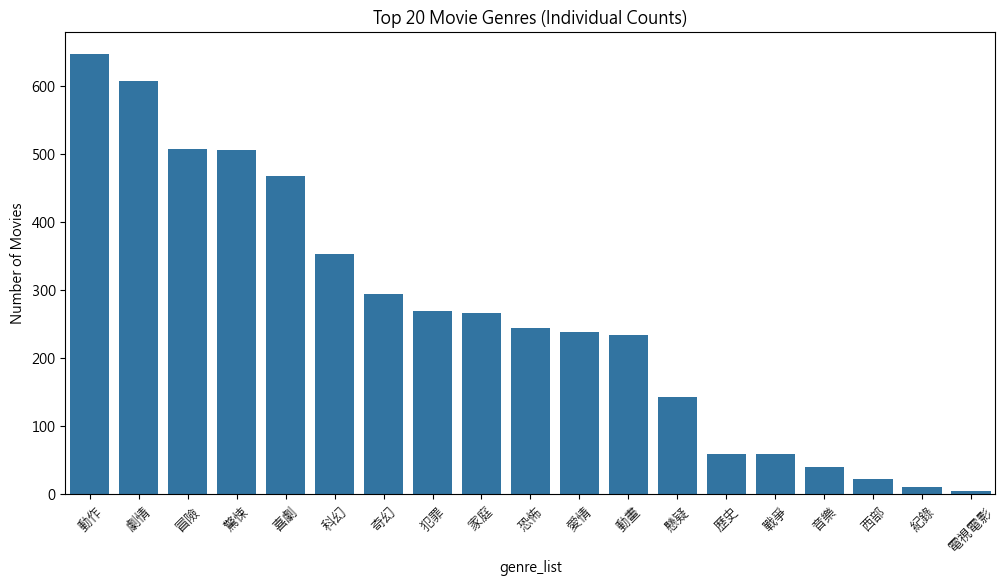

所有類別的數量：
genre_list
動作      647
劇情      608
冒險      507
驚悚      506
喜劇      468
科幻      353
奇幻      295
犯罪      270
家庭      267
恐怖      245
愛情      238
動畫      234
懸疑      143
歷史       59
戰爭       59
音樂       40
西部       23
紀錄       10
電視電影      5
Name: count, dtype: int64


In [7]:
# 步驟 1：先拆解標籤以計算單一標籤的總數
movies['genre_list'] = movies['genre_label'].str.split('、')
df_exploded_temp = movies.explode('genre_list')

# 步驟 2：統計各類別數量
all_genre_counts = df_exploded_temp['genre_list'].value_counts()

# 步驟 3：繪製長條圖
plt.figure(figsize=(12, 6))
# 這裡畫出前 20 個最常見的類別，以免圖表太擠
sns.barplot(x=all_genre_counts.head(20).index, y=all_genre_counts.head(20).values)

plt.title('Top 20 Movie Genres (Individual Counts)')
plt.xticks(rotation=45)
plt.ylabel('Number of Movies')
plt.show()

# 顯示具體的數字給你看
print("所有類別的數量：")
print(all_genre_counts)

In [8]:
# 1. 取得前六名的類別名稱
top_6_genres = all_genre_counts.head(6).index.tolist()
print(f"\n將保留以下前六大類別：{top_6_genres}")

# 2. 在拆解後的資料中，只留下屬於這六類的標籤
df_filtered = df_exploded_temp[df_exploded_temp['genre_list'].isin(top_6_genres)]

# 3. 重新聚合 (Groupby)
# 這裡加入 'words' 欄位的處理
df_final = df_filtered.groupby(df_filtered.index).agg({
    'title': 'first',
    'overview': 'first',
    'words': 'first', # 保留你分好詞的欄位
    'genre_list': lambda x: list(x) 
}).reset_index(drop=True)

# --- 驗證結果 ---
print(f"原始電影總數: {len(movies)}")
print(f"過濾後剩餘電影總數: {len(df_final)}")

# 看看最後一筆資料的樣貌
print("\n將 Explode 完的 genre_list (多 label) 合併回一部電影")
print("處理後的資料：")
print(df_final[['title', 'genre_list', 'words']].head(3))
df_final.head()


將保留以下前六大類別：['動作', '劇情', '冒險', '驚悚', '喜劇', '科幻']
原始電影總數: 1768
過濾後剩餘電影總數: 1666

將 Explode 完的 genre_list (多 label) 合併回一部電影
處理後的資料：
        title genre_list                                              words
0  超級瑪利歐銀河電影版   [喜劇, 冒險]  超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...
1      阿凡達火與燼   [科幻, 冒險]  阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉...
2        極限返航   [科幻, 冒險]  極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到...


,title,overview,words,genre_list
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]"
1,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮...,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉...,"[科幻, 冒險]"
2,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知...,極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到...,"[科幻, 冒險]"
3,降世神通最後的氣宗,安意外得知一股古老力量或許能拯救他的族群免於滅絕在夥伴們的協助下他踏上一段橫跨世界的尋找之旅...,降世 神通 最後 氣宗 意外 得知 一股 古老 力量 拯救 族群 免於 滅絕 夥伴 協助 踏...,"[動作, 冒險]"
4,狸想世界,熱愛動物的梅寶逮到了一個機會藉由新科技讓意識進入到栩栩如生的機器動物身上有了能夠和動物溝通的...,狸想 世界 熱愛 動物 梅寶 逮到 機會 藉由 科技 意識 進入 栩栩如生 機器 動物 身上...,"[科幻, 喜劇, 冒險]"


## 詞彙關係

### 1. 計算 tf-idf 並找出重要詞彙

#### 1.1 建立詞頻矩陣並把詞頻進一步轉成 TF-IDF

In [14]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfTransformer

In [16]:
# Bag of Word
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df_final["words"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成 dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,一一,一上台,一上場,一下,一下子,一不小心,一世,一串,一九八,一九八四年,...,龍馬精神,龍騎士,龐克,龐克女,龐大,龐德,龐然,龐然大物,龐雜,龜毛
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1661,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1662,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1663,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1664,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
transformer = TfidfTransformer()
# 將詞頻矩陣X統計成TF-IDF值
tfidf = transformer.fit_transform(X)

# 轉成dataframe
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf.toarray())

TFIDF_df

,一一,一上台,一上場,一下,一下子,一不小心,一世,一串,一九八,一九八四年,...,龍馬精神,龍騎士,龐克,龐克女,龐大,龐德,龐然,龐然大物,龐雜,龜毛
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1661,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1664,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 1.2 方法1： 取每一個字詞在所有文件裡的TF-IDF平均值

In [18]:
food_tfidf = TFIDF_df.mean().to_frame().reset_index() ## !!
food_tfidf.columns = ["word", "avg"]

food_tfidf.sort_values('avg', ascending = False).head(10)

,word,avg
780,世界,0.012708
10780,故事,0.011133
15413,發現,0.011024
80,一場,0.010295
62,一名,0.010141
15015,生活,0.009967
1576,人類,0.009902
1723,任務,0.009798
7667,展開,0.009243
17125,美國,0.008642


#### 1.3 方法2： 取每份文件裡TF-IDF值最大的前10個字詞當為常用字詞，再取每一個字詞在常用字詞中出現頻率

In [19]:
toptens = TFIDF_df.copy()
toptens.insert(0, 'doc_id', toptens.index+1)

toptens

,doc_id,一一,一上台,一上場,一下,一下子,一不小心,一世,一串,一九八,...,龍馬精神,龍騎士,龐克,龐克女,龐大,龐德,龐然,龐然大物,龐雜,龜毛
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1661,1662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1662,1663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1663,1664,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1664,1665,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
toptens = toptens.melt(id_vars = "doc_id", var_name = "word", value_name = 'tfidf')
toptens

,doc_id,word,tfidf
0,1,一一,0.0
1,2,一一,0.0
2,3,一一,0.0
3,4,一一,0.0
4,5,一一,0.0
...,...,...,...
39214303,1662,龜毛,0.0
39214304,1663,龜毛,0.0
39214305,1664,龜毛,0.0
39214306,1665,龜毛,0.0


In [21]:
(
    # 從每篇文章挑選出tf-idf最大的前十個詞
    toptens.groupby("doc_id").apply(lambda x : x.nlargest(10, "tfidf")).reset_index(drop=True)

    # 計算每個詞被選中的次數
    .groupby(['word'],as_index=False).size()

).sort_values('size', ascending=False).head(10) # 排序看前十名

,word,size
7558,殺手,26
1034,人類,25
12105,飾演,24
3501,地球,23
10117,英雄,22
4510,家族,22
9414,約翰,21
498,世界,19
6975,最佳,18
11330,遊戲,18


### 2. N-gram 分析

#### 2.1 bigram

In [24]:
from nltk import ngrams, FreqDist

In [25]:
# 設定 ngram 斷詞 function
def ngram_getToken(row, n):
    # 進行斷詞
    seg_list = jieba.lcut(row)

    # 篩選掉停用字與字元數小於1的詞彙
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1]

    # ngram斷詞
    seg_list = ngrams(seg_list, n)
    seg_list = [" ".join(w) for w in list(seg_list)]

    return seg_list

In [26]:
movie_bigram = df_final.copy()

movie_bigram["word"] = movie_bigram['overview'].apply(lambda row: ngram_getToken(row, 2))
movie_bigram = movie_bigram.explode('word')

movie_bigram.head(3)

,title,overview,words,genre_list,word
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]",面對 反派
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]",反派 勢力
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]",勢力 再度


In [27]:
# 計算每個組合出現的次數
movie_bigram_count = movie_bigram['word'].value_counts().reset_index()

movie_bigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,展開 一場,46
1,超級 英雄,38
2,故事 描述,24
3,意外 發現,24
4,冒險 旅程,22
5,拯救 世界,21
6,攜手 合作,20
7,故事 發生,20
8,未來 世界,19
9,故事 敘述,18


#### 2.2 trigram

In [28]:
movie_trigram = df_final.copy()

movie_trigram["word"] = movie_trigram['overview'].apply(lambda row: ngram_getToken(row, 3))
movie_trigram = movie_trigram.explode('word')

movie_trigram.head(3)

,title,overview,words,genre_list,word
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]",面對 反派 勢力
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]",反派 勢力 再度
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]",勢力 再度 崛起


In [29]:
# 計算每個組合出現的次數
movie_trigram_count = movie_trigram['word'].value_counts().reset_index()

movie_trigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,李奧納多 狄卡皮 歐飾,5
1,美國 隊長 英雄,5
2,隊長 英雄 內戰,5
3,故事 背景 設定,5
4,獲得 奧斯卡 最佳,5
5,最佳 改編 劇本,5
6,漫威 電影 宇宙,4
7,布萊德 彼特 飾演,4
8,貓捉 老鼠 遊戲,4
9,傑克 葛倫 霍飾,4


#### 2.3 使用自建自典

In [30]:
# 新增電影相關自定義字典
# 要修改路徑
jieba.load_userdict('./dict/movie_lexicon.txt')

##### bigram


In [31]:
# 剛才的斷詞結果沒有使用新增的辭典，因此我們重新進行斷詞
data2 = df_final.copy()
data2['word'] = data2['overview'].apply(lambda row: ngram_getToken(row, 2))
data2 = data2.explode('word')

# 計算每個組合出現的次數
data2_bigram_count = data2['word'].value_counts().reset_index()
data2_bigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,展開 一場,46
1,故事 描述,24
2,意外 發現,24
3,冒險 旅程,22
4,拯救 世界,21
5,故事 發生,20
6,未來 世界,19
7,故事 敘述,18
8,故事 講述,17
9,平靜 生活,14


##### trigram

In [32]:
# 剛才的斷詞結果沒有使用新增的辭典，因此我們重新進行斷詞
data3 = df_final.copy()
data3['word'] = data3['overview'].apply(lambda row: ngram_getToken(row, 3))
data3 = data3.explode('word')

# 計算每個組合出現的次數
data3_trigram_count = data3['word'].value_counts().reset_index()
data3_trigram_count.sort_values('count', ascending=False).head(10)

,word,count
0,獲得 奧斯卡 最佳,5
1,過著 平靜 生活,4
2,真實 事件 改編,4
3,踏上 危險 旅程,3
4,超級 瑪利 兄弟,3
5,之間 做出 抉擇,3
6,足以 改變 人生,3
7,陷入 空前 危機,3
8,展開 一場 激烈,3
9,追隨 父親 腳步,3


#### 2.4 Bigram視覺化

In [33]:
import networkx as nx

In [34]:
bigramfdist = df_final.copy()
bigramfdist["word"] = bigramfdist['overview'].apply(lambda row: ngram_getToken(row, 2))
bigramfdist = bigramfdist.explode('word')

bigramfdist.head(3)

,title,overview,words,genre_list,word
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]",面對 反派
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]",反派 勢力
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[喜劇, 冒險]",勢力 再度


In [35]:
bigramfdist['word'] = bigramfdist['word'].astype(str)
bigramfdist = FreqDist(bigramfdist['word'].apply(lambda x: tuple(x.split(' '))))
bigramfdist.most_common(5)

[(('展開', '一場'), 46),
 (('故事', '描述'), 24),
 (('意外', '發現'), 24),
 (('冒險', '旅程'), 22),
 (('拯救', '世界'), 21)]

In [36]:
# 建立bigram和count的dictionary
# 這裡取最多的前50項
d = {k:v for k,v in bigramfdist.most_common(50)}

# Create network plot
G = nx.Graph()

# 建立 nodes 間的連結
for k, v in [d][0].items():
    G.add_edge(k[0], k[1], weight=v) # nodes：詞彙，weight：組合出現頻率

# 取得調整edge權重
weights = [w[2]['weight']*0.05 for w in  G.edges(data=True)]

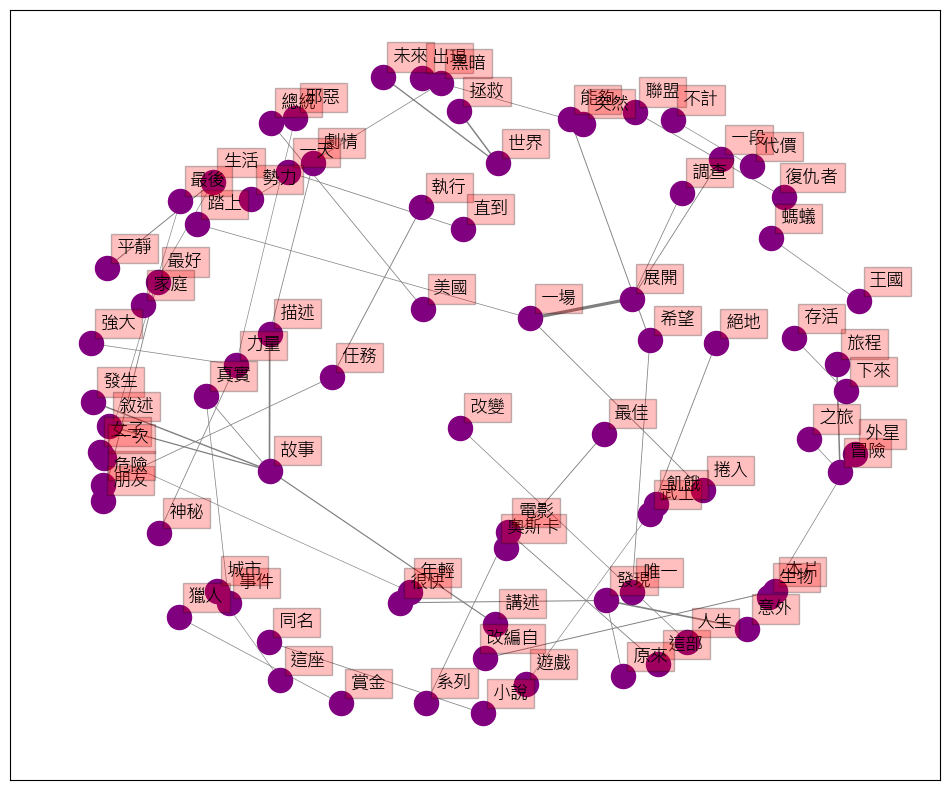

In [37]:
fig, ax = plt.subplots(figsize=(12, 10))

pos = nx.spring_layout(G, k=1.5)

# networks
nx.draw_networkx(G, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='purple',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=13)

plt.show()

### 3. Pairwise correlation

#### 3.1 計算詞彙相關性

In [38]:
data_cor = movies.copy()

data_cor["words"] = data_cor["content"].apply(getToken).map(" ".join)
data_cor.head(3)

,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label,content,words,genre_list
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫,超級瑪利歐銀河電影版面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[家庭, 喜劇, 冒險, 奇幻, 動畫]"
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮...,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達火與燼,False,7.372,2645,科幻、冒險、奇幻,阿凡達火與燼這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人...,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉...,"[科幻, 冒險, 奇幻]"
3,False,/8Tfys3mDZVp4tNoH2ktm06a0Tau.jpg,687163,en,Project Hail Mary,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知...,262.4292,/aHFJ7HM6Gly2KFqs8MaIXoOseii.jpg,2026-03-15,極限返航,False,8.216,1561,科幻、冒險,極限返航科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因...,極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到...,"[科幻, 冒險]"


In [39]:
# Bag of Word
# 篩選至少出現在5篇文章以上且詞頻前300的詞彙
vectorizer = CountVectorizer(min_df = 5, max_features = 300)
X = vectorizer.fit_transform(data_cor["words"])
vocabulary = vectorizer.get_feature_names_out()

# 轉成dataframe
DTM_df = pd.DataFrame(columns = vocabulary, data = X.toarray())
DTM_df

,一位,一同,一名,一場,一天,一家,一對,一次,一段,一直,...,電影,面對,面臨,飾演,驚人,魔法,麥克,黑幫,黑暗,龐德
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1763,0,0,0,1,0,0,0,1,0,0,...,0,2,0,0,0,0,1,0,0,0
1764,0,0,2,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1765,1,0,0,2,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1766,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0


In [40]:
# 計算詞之間的相關係數
corr_matrix = np.corrcoef(DTM_df.T)

# 轉成dataframe
Cor_df = pd.DataFrame(corr_matrix, index = DTM_df.columns, columns = DTM_df.columns)

Cor_df.insert(0, 'word1', Cor_df.columns)
Cor_df.reset_index(inplace = True, drop = True)

Cor_df

,word1,一位,一同,一名,一場,一天,一家,一對,一次,一段,...,電影,面對,面臨,飾演,驚人,魔法,麥克,黑幫,黑暗,龐德
0,一位,1.000000,-0.032205,-0.008810,0.003794,0.111730,0.004050,0.000583,-0.000524,0.041940,...,0.005915,0.004052,-0.014998,-0.001043,-0.002299,0.000041,-0.021348,-0.019259,-0.000124,-0.016166
1,一同,-0.032205,1.000000,0.011812,0.000204,-0.014541,0.021894,-0.030962,-0.002606,0.004753,...,0.043050,0.046656,0.003390,0.009677,-0.025565,0.055313,0.001997,-0.019317,-0.003952,-0.012331
2,一名,-0.008810,0.011812,1.000000,0.043076,0.032460,-0.000829,0.057291,-0.018146,0.017130,...,0.001392,-0.011984,0.007862,0.021614,0.029995,-0.027821,-0.024723,0.007980,0.006906,0.036808
3,一場,0.003794,0.000204,0.043076,1.000000,0.035964,-0.018888,0.029939,0.011633,-0.007046,...,-0.012985,0.032428,0.010094,0.004033,0.019795,-0.008744,0.008544,0.059122,-0.008617,-0.003406
4,一天,0.111730,-0.014541,0.032460,0.035964,1.000000,0.050473,0.013348,0.007288,0.051788,...,0.005021,-0.002748,0.026055,-0.013419,0.031222,0.039002,0.067922,-0.021537,-0.006254,-0.013748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,魔法,0.000041,0.055313,-0.027821,-0.008744,0.039002,-0.009655,-0.002575,-0.006504,-0.010295,...,-0.019656,-0.027531,0.005964,-0.010128,-0.005505,1.000000,-0.000739,-0.012050,-0.006199,-0.007692
296,麥克,-0.021348,0.001997,-0.024723,0.008544,0.067922,0.003824,-0.003002,-0.014542,-0.014635,...,-0.015792,0.030112,0.064886,-0.008654,0.002589,-0.000739,1.000000,0.048307,-0.005624,-0.005978
297,黑幫,-0.019259,-0.019317,0.007980,0.059122,-0.021537,-0.010138,0.044422,0.002935,0.092091,...,-0.004547,0.013314,0.022639,-0.009939,0.009108,-0.012050,0.048307,1.000000,0.049018,-0.009103
298,黑暗,-0.000124,-0.003952,0.006906,-0.008617,-0.006254,-0.001258,-0.026064,-0.007026,0.009657,...,0.021057,0.119315,-0.015202,-0.027250,-0.002662,-0.006199,-0.005624,0.049018,1.000000,-0.014878


In [41]:
word_cor_df = Cor_df.melt(id_vars = 'word1', var_name = 'word2', value_name = 'cor')

# 去除兩個詞相同的情況
word_cor_df = word_cor_df[word_cor_df["word1"] != word_cor_df["word2"]]

# 3. 去除「鏡像重複」的配對（例如：[國王, 公主] 與 [公主, 國王]）
# 將 word1 和 word2 的內容按字元順序重新排列，讓鏡像配對變成完全一樣的字串組合
word_cor_df[['word1', 'word2']] = np.sort(word_cor_df[['word1', 'word2']], axis=1)
# 接著直接刪除重複的組合即可
word_cor_df = word_cor_df.drop_duplicates(subset=['word1', 'word2'])

word_cor_df.sort_values('cor', ascending=False).head(10)

,word1,word2,cor
68099,系列,龐德,0.493084
26568,奧斯卡,最佳,0.454876
13576,公主,國王,0.450959
48859,旅程,踏上,0.399247
23564,地球,星際,0.391254
72599,英國,龐德,0.374214
32874,導演,本片,0.369974
4190,一部,電影,0.367931
13699,公主,王國,0.361414
49064,星球,星際,0.355501


#### 3.2 和"龐德"與"國王"最相關的詞彙

In [42]:
text_1 = "龐德"
text_2 = "國王"

In [43]:
text_1_sum = word_cor_df[(word_cor_df["word1"] == text_1) | (word_cor_df["word2"] == text_1)].sort_values(by = ['cor'], ascending = False).head(10)
text_2_sum = word_cor_df[(word_cor_df["word1"] == text_2) | (word_cor_df["word2"] == text_2)].sort_values(by = ['cor'], ascending = False).head(10)
text_1_sum['other_word'] = np.where(text_1_sum['word1'] == text_1, text_1_sum['word2'], text_1_sum['word1'])
text_2_sum['other_word'] = np.where(text_2_sum['word1'] == text_2, text_2_sum['word2'], text_2_sum['word1'])

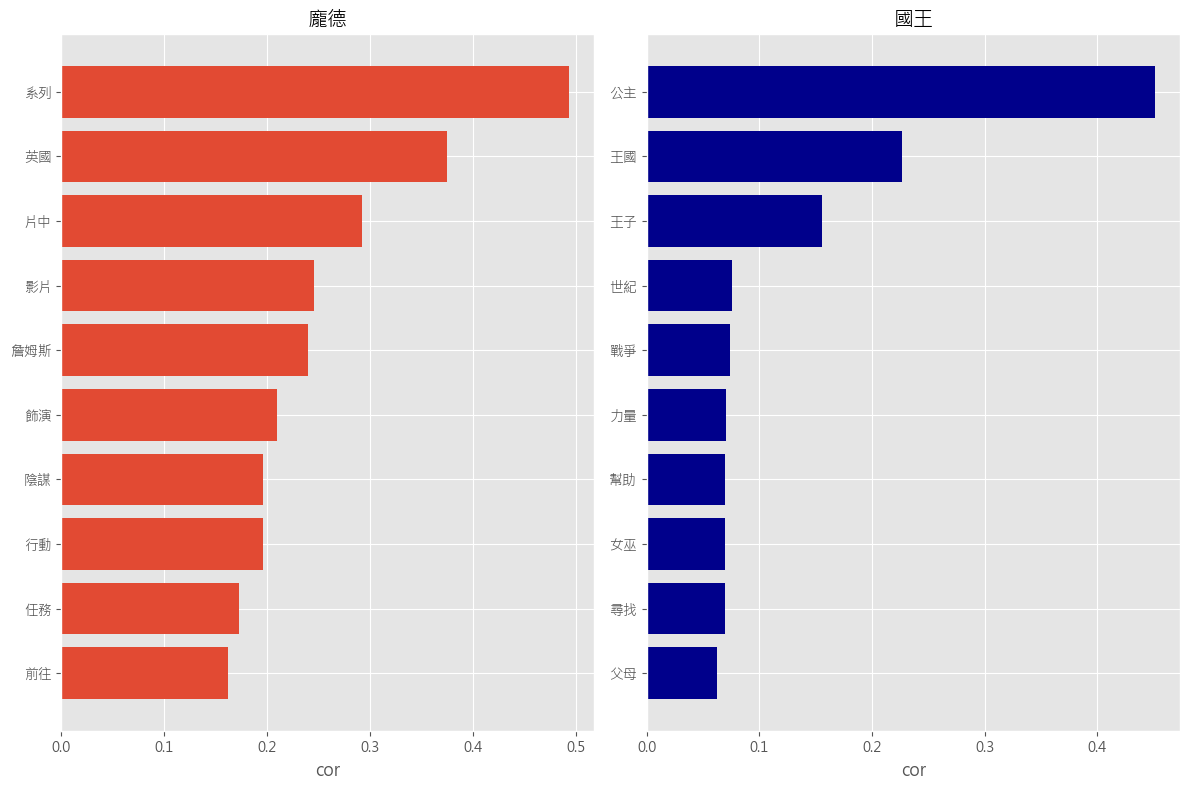

In [44]:
plt.figure(figsize=(12,8))   # 顯示圖框架大小 (寬,高)
plt.style.use("ggplot")      # 使用ggplot主題樣式

# ⚠️ 解決 Mac/Windows 顯示中文標籤會變成方塊(亂碼)的問題
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang HK', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False # 讓負號正常顯示

# --- 左圖：text_1 ---
plt.subplot(121)
plt.title(text_1)
plt.xlabel('cor')
# 這裡把原來的 text_1_sum['word2'] 換成我們剛做好的 text_1_sum['other_word']
plt.barh(text_1_sum['other_word'], text_1_sum['cor'])
plt.gca().invert_yaxis()

# --- 右圖：text_2 ---
plt.subplot(122)
plt.title(text_2)
plt.xlabel('cor')
# 這裡把原來的 text_2_sum['word2'] 換成我們剛做好的 text_2_sum['other_word']
plt.barh(text_2_sum['other_word'], text_2_sum['cor'], color="darkblue")
plt.gca().invert_yaxis()

# 調整子圖間距，避免文字重疊
plt.tight_layout() 
plt.show()

#### 3.3 詞彙關係圖(詞頻前60與相關性高於0.15)

In [45]:
# 透過DTM找出詞頻前60高的詞彙
most_freq_df = DTM_df.sum().sort_values(ascending=False).head(60).reset_index().rename(columns={'index':'word', 0:'count'})

most_freq_word = most_freq_df['word'].tolist()

In [46]:
# 保留存在詞頻前60高之詞彙的組合
filtered_df = word_cor_df[(word_cor_df['word1'].isin(most_freq_word)) & (word_cor_df['word2'].isin(most_freq_word))]

# 篩選出相關係數大於0.15的組合
filtered_df = filtered_df[filtered_df['cor'] > 0.15]
filtered_df.reset_index(inplace=True, drop=True)
filtered_df

,word1,word2,cor
0,一場,冒險,0.167507
1,一場,展開,0.278254
2,世界,人類,0.171316
3,世界,拯救,0.182282
4,人類,地球,0.251049
5,人類,未來,0.205119
6,任務,行動,0.155623
7,力量,擁有,0.177401
8,力量,邪惡,0.158767
9,地球,發現,0.194308


In [47]:
# Create network plot
g = nx.Graph()

# 建立 nodes 間的連結
for i in range(len(filtered_df)):
    g.add_edge(filtered_df["word1"][i], filtered_df["word2"][i], weight=filtered_df["cor"][i])

# 取得edge權重
weights = [w[2]['weight']*5 for w in  g.edges(data=True)]

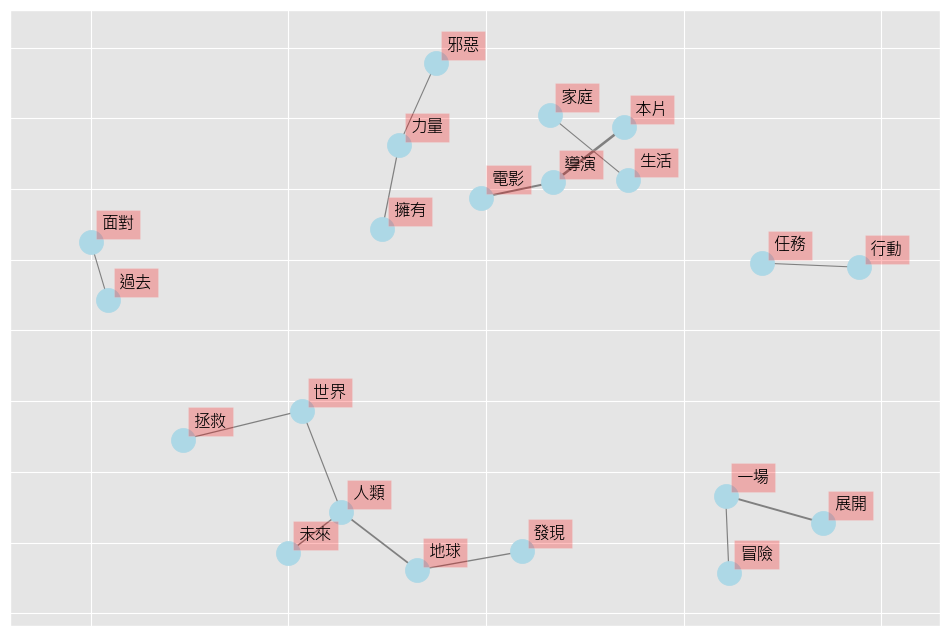

In [48]:
fig, ax = plt.subplots(figsize=(12, 8))

pos = nx.spring_layout(g, k=0.3)

# networks
nx.draw_networkx(g, pos,
                 font_size=16,
                 width=weights,
                 edge_color='grey',
                 node_color='lightblue',
                 with_labels = False,
                 ax=ax)

# 增加 labels
for key, value in pos.items():
    x, y = value[0]+.07, value[1]+.045
    ax.text(x, y,
            s=key,
            bbox=dict(facecolor='red', alpha=0.25),
            horizontalalignment='center', fontsize=12)

plt.show()

### 4. 計算影片描述相似度

#### 4.1 計算 tf-idf

In [49]:
data_cos = data_cor.copy()
data_cos.head(2)

,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label,content,words,genre_list
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打...,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫,超級瑪利歐銀河電影版面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公...,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大...,"[家庭, 喜劇, 冒險, 奇幻, 動畫]"
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮...,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達火與燼,False,7.372,2645,科幻、冒險、奇幻,阿凡達火與燼這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人...,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉...,"[科幻, 冒險, 奇幻]"


In [50]:
transformer = TfidfTransformer()
print(transformer)
# 將詞頻矩陣X統計成TF-IDF值
tfidf = transformer.fit_transform(X)

# 轉成dataframe
TFIDF_df = pd.DataFrame(columns = vocabulary, data = tfidf.toarray())
TFIDF_df

TfidfTransformer()


,一位,一同,一名,一場,一天,一家,一對,一次,一段,一直,...,電影,面對,面臨,飾演,驚人,魔法,麥克,黑幫,黑暗,龐德
0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.217570,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
1,0.000000,0.306769,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.282286,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.244953,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.274183,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.249312,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1763,0.000000,0.000000,0.000000,0.136627,0.0,0.0,0.0,0.179893,0.000000,0.0,...,0.000000,0.311079,0.000000,0.000000,0.0,0.0,0.244459,0.0,0.0,0.0
1764,0.000000,0.000000,0.279612,0.133580,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.170269,0.0,0.0,0.000000,0.0,0.0,0.0
1765,0.257264,0.000000,0.000000,0.452723,0.0,0.0,0.0,0.000000,0.000000,0.0,...,0.269325,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0
1766,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.096277,0.000000,0.0,...,0.086999,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0


#### 4.2 取得特定電影的相關電影

In [52]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_matrix = cosine_similarity(tfidf.toarray(), tfidf.toarray())

cos_df = pd.DataFrame(cosine_matrix[0], columns = ['cos_similarity'])
cos_df

,cos_similarity
0,1.000000
1,0.000000
2,0.000000
3,0.058304
4,0.054243
...,...
1763,0.067681
1764,0.059768
1765,0.070602
1766,0.000000


In [53]:
# cos_df = cos_df.merge(data_cos, how = 'left', left_index=True, right_index=True)
# cos_df.loc[:,["cos_similarity", "title"]].sort_values(by=['cos_similarity'], ascending=False).head(10)

# 由於 data_cos 有被過濾過，導致第二筆資料的 id 並非 1 而是 2
# 需要用 .values 解決索引問題
cos_df['title'] = data_cos['title'].values
cos_df.loc[:,["cos_similarity", "title"]].sort_values(by=['cos_similarity'], ascending=False).head(10)

,cos_similarity,title
0,1.000000,超級瑪利歐銀河電影版
1129,0.666650,史瑞克三世
649,0.594670,史瑞克
1247,0.525346,神話
749,0.503162,睡美人
906,0.490249,花木蘭
1064,0.451747,黑魔女
793,0.449777,羊男的迷宮
937,0.442395,蟲蟲危機
1152,0.438045,曼哈頓奇緣


In [54]:
cos_df_self = pd.DataFrame(cosine_matrix[576], columns=['cos_similarity'])

# 用 .values 繞過索引問題
cos_df_self['title'] = data_cos['title'].values
cos_df_self.loc[:, ["cos_similarity", "title"]].sort_values(by=['cos_similarity'], ascending=False).head(10)

,cos_similarity,title
576,1.000000,飢餓遊戲黎明收割
1233,0.741473,野蠻遊戲瘋狂叢林
525,0.733169,飢餓遊戲星火燎原
80,0.709746,弒婚遊戲
830,0.701085,野蠻遊戲全面晉級
1314,0.678036,致命遊戲
655,0.669974,飢餓遊戲
305,0.639205,飢餓遊戲鳴鳥與游蛇之歌
30,0.608511,弒婚遊戲度開局
811,0.581067,危險性遊戲


In [55]:
# 指定要查的電影標題列表
movie_titles = [
    "飢餓遊戲黎明收割",
    "野蠻遊戲瘋狂叢林",
    "飢餓遊戲星火燎原",
    "弒婚遊戲",
    "野蠻遊戲全面晉級",
    "致命遊戲",
    "飢餓遊戲",
    "飢餓遊戲鳴鳥與游蛇之歌",
    "弒婚遊戲度開局",
    "危險性遊戲"
]

# 從 movies 資料中篩選出指定標題的電影，並只保留 title 和 overview 欄位
selected_movies = movies[movies['title'].isin(movie_titles)][['title', 'overview']]
selected_movies

,title,overview
34,弒婚遊戲度開局,在變態富豪拉多馬斯家族的殺人躲貓貓遊戲中倖存後新娘葛蕾絲本以為一切都在遊戲結束後殺戮就隨之終...
97,弒婚遊戲,葛雷絲飾嫁入一個以桌游發跡致富的豪門拉多馬斯家族但這個家族有個怪異的傳統就是每當家族有新成員...
357,飢餓遊戲鳴鳥與游蛇之歌,歲的史諾湯姆布萊斯飾將擔任第十屆飢餓遊戲的導師期待能透過指導貢品贏得比賽振興落魄的家族不料他...
614,飢餓遊戲星火燎原,電影描述凱妮絲珍妮佛勞倫斯飾和比德喬許哈契森飾扭轉不可能獲勝的的情勢從第屆飢餓遊戲生還攜手返...
676,飢餓遊戲黎明收割,故事發生在首集飢餓遊戲的年前年輕的黑密契被選中參加第屆飢餓遊戲同時也是第屆大旬祭大旬祭每年舉...
771,飢餓遊戲,在北美洲這塊廢墟大陸上有個新興國家施惠國國內有十二個行政區以及一座被行政區圍繞的富饒都城至高...
937,危險性遊戲,凱薩琳莎拉米雪兒吉蘭和薩巴斯丁雷恩菲利浦是一對富家異姓姊弟由於凱薩琳在暑假時被花花公子寇特拋...
957,野蠻遊戲全面晉級,在全新的野蠻遊戲全面晉級中前一集角色再度聚首但遊戲的格局卻早已改變當四位主角重返野蠻遊戲試圖...
1405,野蠻遊戲瘋狂叢林,名留校察看的青少年意外發現一款電玩遊戲點選開始後竟離奇被帶進電玩世界裡成為遊戲中的電玩角色展...
1493,致命遊戲,尼可拉斯范歐頓邁克道格拉斯飾是一個事業有成的銀行家雖然有家財萬貫然而他的婚姻破裂讓他一直過著...


#### 4.3 記錄每部電影與相關係數>0.5的其他電影

In [56]:
# 自動化執行：記錄每部電影與相關係數>0.5的其他電影

# 步驟 1：建立結果儲存清單
related_movies_above_threshold = []

# 步驟 2：遍歷每部電影
for movie_idx in range(len(data_cos)):
    # 取得該電影與所有其他電影的相似度
    cos_similarities = cosine_matrix[movie_idx]
    
    # 排除自己本身 - 明確排除掉電影自己的索引
    # 找出相似度 > 0.5 的電影索引（同時排除自己）
    similar_indices = np.where((cos_similarities > 0.5) & (np.arange(len(cos_similarities)) != movie_idx))[0]
    
    # 如果有相關係數 > 0.5 的電影，記錄下來
    if len(similar_indices) > 0:
        movie_title = data_cos.iloc[movie_idx]['title']
        max_similarity = cos_similarities[similar_indices].max()
        
        # 建立該電影的詳細資訊
        related_movies_above_threshold.append({
            'movie_id': movie_idx,
            'movie_title': movie_title,
            'max_similarity': max_similarity,
            'similar_count': len(similar_indices),
            'similar_movie_ids': list(similar_indices),
            'similar_movies': [data_cos.iloc[idx]['title'] for idx in similar_indices],
            'similarities': [cos_similarities[idx] for idx in similar_indices]
        })

# 步驟 3：轉成 DataFrame 方便查看
related_df = pd.DataFrame(related_movies_above_threshold)

# 根據 max_similarity 從高到低排序
related_df = related_df.sort_values('max_similarity', ascending=False).reset_index(drop=True)

print(f"共有 {len(related_df)} 部電影與其他電影的相關係數 > 0.5（不含自己）")
print("\n按最高相似度排序的前 10 部電影：")
display(related_df[['movie_id', 'movie_title', 'max_similarity', 'similar_count']].head(10))

# 步驟 4：顯示詳細的對應關係（每部電影的相似電影）
print("\n\n每部電影的相似電影詳細列表（相關係數 > 0.5，不含自己）：")
print("="*80)
for idx, row in related_df.head(20).iterrows():
    print(f"\n【ID: {row['movie_id']}】{row['movie_title']}")
    print(f"  最高相似度: {row['max_similarity']:.4f}")
    print(f"  找到 {row['similar_count']} 部相似電影：")
    for sim_id, sim_title, sim_score in zip(row['similar_movie_ids'], row['similar_movies'], row['similarities']):
        print(f"    - ID {sim_id}: {sim_title} (相關係數: {sim_score:.4f})")

共有 555 部電影與其他電影的相關係數 > 0.5（不含自己）

按最高相似度排序的前 10 部電影：


,movie_id,movie_title,max_similarity,similar_count
0,1401,刀鋒戰士,0.902038,12
1,547,刀鋒戰士,0.902038,12
2,427,七武士,0.891235,5
3,698,末代武士,0.891235,3
4,1392,玩命快遞,0.886091,8
5,1587,玩命快遞,0.886091,7
6,852,天才的禮物,0.875227,7
7,905,刀鋒戰士,0.872588,12
8,705,暮光之城蝕,0.851023,12
9,1363,生死關頭,0.824732,11




每部電影的相似電影詳細列表（相關係數 > 0.5，不含自己）：

【ID: 1401】刀鋒戰士
  最高相似度: 0.9020
  找到 12 部相似電影：
    - ID 69: 暮光之城破曉 (相關係數: 0.7833)
    - ID 194: 暮光之城無懼的愛 (相關係數: 0.5534)
    - ID 278: 凡赫辛 (相關係數: 0.7638)
    - ID 473: 吸血鬼諾斯費拉圖 (相關係數: 0.6609)
    - ID 547: 刀鋒戰士 (相關係數: 0.9020)
    - ID 585: 暮光之城新月 (相關係數: 0.7103)
    - ID 705: 暮光之城蝕 (相關係數: 0.8510)
    - ID 858: 尖叫旅社 (相關係數: 0.7903)
    - ID 899: 尖叫旅社 (相關係數: 0.6112)
    - ID 905: 刀鋒戰士 (相關係數: 0.8726)
    - ID 927: 夜訪吸血鬼 (相關係數: 0.7809)
    - ID 1529: 暮光之城破曉 (相關係數: 0.7300)

【ID: 547】刀鋒戰士
  最高相似度: 0.9020
  找到 12 部相似電影：
    - ID 69: 暮光之城破曉 (相關係數: 0.7544)
    - ID 194: 暮光之城無懼的愛 (相關係數: 0.5619)
    - ID 278: 凡赫辛 (相關係數: 0.7563)
    - ID 473: 吸血鬼諾斯費拉圖 (相關係數: 0.6332)
    - ID 585: 暮光之城新月 (相關係數: 0.6867)
    - ID 705: 暮光之城蝕 (相關係數: 0.8307)
    - ID 858: 尖叫旅社 (相關係數: 0.7858)
    - ID 899: 尖叫旅社 (相關係數: 0.6049)
    - ID 905: 刀鋒戰士 (相關係數: 0.8644)
    - ID 927: 夜訪吸血鬼 (相關係數: 0.7752)
    - ID 1401: 刀鋒戰士 (相關係數: 0.9020)
    - ID 1529: 暮光之城破曉 (相關係數: 0.7175)

【ID: 427】七武士
  最高相似度: 0.8

In [57]:
# 補充分析：統計與篩選

# 統計相似電影最多與最少的電影
print("\n最高相似度的 Top 10：")
top_correlation = related_df.nlargest(10, 'max_similarity')[['movie_id', 'movie_title', 'max_similarity', 'similar_count']]
display(top_correlation)

print("\n最多相似電影的 Top 10：")
top_similar = related_df.nlargest(10, 'similar_count')[['movie_id', 'movie_title', 'max_similarity', 'similar_count']]
display(top_similar)

# 建立簡易查詢函數
def find_similar_movies(movie_id):
    """查詢特定電影的相似電影"""
    result = related_df[related_df['movie_id'] == movie_id]
    if len(result) == 0:
        print(f"電影 ID {movie_id} 沒有相關係數 > 0.5 的相似電影")
    else:
        row = result.iloc[0]
        print(f"\n【ID: {row['movie_id']}】{row['movie_title']}")
        print(f"最高相似度: {row['max_similarity']:.4f}")
        print(f"相似電影清單（按相似度排序）：\n")
        
        # 按相似度從高到低排序
        sorted_indices = sorted(range(len(row['similarities'])), 
                               key=lambda i: row['similarities'][i], 
                               reverse=True)
        
        for rank, i in enumerate(sorted_indices, 1):
            print(f"{rank}. ID {row['similar_movie_ids'][i]}: {row['similar_movies'][i]}")
            print(f"   相關係數: {row['similarities'][i]:.4f}\n")

# 測試查詢函數
print("\n"+"="*80)
print("查詢範例：")
find_similar_movies(13)  # 相關係數 < 0.5，無結果
find_similar_movies(124)  # 相關係數 > 0.5，有結果


最高相似度的 Top 10：


,movie_id,movie_title,max_similarity,similar_count
0,1401,刀鋒戰士,0.902038,12
1,547,刀鋒戰士,0.902038,12
2,427,七武士,0.891235,5
3,698,末代武士,0.891235,3
4,1392,玩命快遞,0.886091,8
5,1587,玩命快遞,0.886091,7
6,852,天才的禮物,0.875227,7
7,905,刀鋒戰士,0.872588,12
8,705,暮光之城蝕,0.851023,12
9,1363,生死關頭,0.824732,11



最多相似電影的 Top 10：


,movie_id,movie_title,max_similarity,similar_count
17,186,黃昏三鏢客,0.791206,15
31,1102,機械公敵,0.773209,13
191,1451,絕地騎士,0.632351,13
0,1401,刀鋒戰士,0.902038,12
1,547,刀鋒戰士,0.902038,12
7,905,刀鋒戰士,0.872588,12
8,705,暮光之城蝕,0.851023,12
21,927,夜訪吸血鬼,0.780893,12
36,1569,殺戮時刻,0.763815,12
62,576,飢餓遊戲黎明收割,0.741473,12



查詢範例：
電影 ID 13 沒有相關係數 > 0.5 的相似電影

【ID: 124】你的名字
最高相似度: 0.5111
相似電影清單（按相似度排序）：

1. ID 1232: 北極特快車
   相關係數: 0.5111



### 5. Ngram 預測模型

#### 5.1 建立 bigram 預測模型

In [61]:
from collections import Counter, namedtuple

In [58]:
data3 = movies.copy()
sen_tokens = data3.content.apply(getToken).tolist()

In [59]:
def ngram(documents, N=2):
    ngram_prediction = dict()
    total_grams = list()
    words = list()
    Word = namedtuple('Word', ['word', 'prob'])

    for doc in documents:
        # 加上開頭和結尾 tag
        split_words = ['<s>'] + list(doc) + ['</s>']
        # 計算分子
        [total_grams.append(tuple(split_words[i:i+N])) for i in range(len(split_words)-N+1)]
        # 計算分母
        [words.append(tuple(split_words[i:i+N-1])) for i in range(len(split_words)-N+2)]

    total_word_counter = Counter(total_grams)
    word_counter = Counter(words)

    for key in total_word_counter:
        word = ''.join(key[:N-1])
        if word not in ngram_prediction:
            ngram_prediction.update({word: set()})

        next_word_prob = total_word_counter[key]/word_counter[key[:N-1]] #P(B|A)
        w = Word(key[-1], '{:.3g}'.format(next_word_prob))
        ngram_prediction[word].add(w)

    return ngram_prediction

In [62]:
# Bigram預測模型為例
bi_prediction = ngram(sen_tokens, N=2)

#### 5.2 預測"劇情"與"魔法"後會出現甚麼字

In [63]:
text = '劇情'
next_words = list(bi_prediction[text])
next_words.sort(key = lambda s: s[1], reverse = True)
for next_word in next_words[:5]:
    print('next word: {}, probability: {}'.format(next_word.word, next_word.prob))

next word: 描述, probability: 0.261
next word: 敘述, probability: 0.109
next word: 接續, probability: 0.087
next word: 講述, probability: 0.0652
next word: 發展, probability: 0.0435


In [64]:
text = '魔法'
next_words = list(bi_prediction[text])
next_words.sort(key = lambda s: s[1], reverse = True)
for next_word in next_words[:5]:
    print('next word: {}, probability: {}'.format(next_word.word, next_word.prob))

next word: 世界, probability: 0.117
next word: 公主, probability: 0.05
next word: 生物, probability: 0.0333
next word: 學院, probability: 0.0333
next word: 學校, probability: 0.0333


#### 5.3 驗證 bigram 的預測結果出現在哪裡

In [65]:
def search_movies(keyword):
    """
    搜尋movies資料表中，title或overview包含指定關鍵字的電影，
    並列出前5部的title以及overview。
    
    Parameters:
    keyword (str): 要搜尋的關鍵字
    
    Returns:
    pandas.DataFrame: 包含title和overview的DataFrame
    """
    # 在title或overview中搜尋包含關鍵字的電影
    filtered_movies = movies[
        movies['title'].str.contains(keyword, na=False, case=False) |
        movies['overview'].str.contains(keyword, na=False, case=False)
    ]
    
    # 選擇前5部電影，並只顯示title和overview欄位
    result = filtered_movies.head(10)[['title', 'overview']]
    
    return result

# 測試函數：搜尋包含"喜歡若瑪"的電影
search_movies("魔法學校")

,title,overview
196,哈利波特火盃的考驗,霍格華茲魔法學校舉行停辦多年的三巫鬥法大賽全校師生為此興奮不已當火盃選出哈利波特作為第四位鬥...
288,哈利波特死神的聖物,魔法世界已成為佛地魔爪牙肆虐的危險之地長久以來令人畏懼的戰爭已開打食死人控制了魔法部霍格華茲...


# 分類任務

### 查看目前電影分別有幾類 label 數的統計

C:\Users\User\AppData\Local\Temp\ipykernel_32544\2377169214.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_count_dist.index, y=label_count_dist.values, palette='viridis')


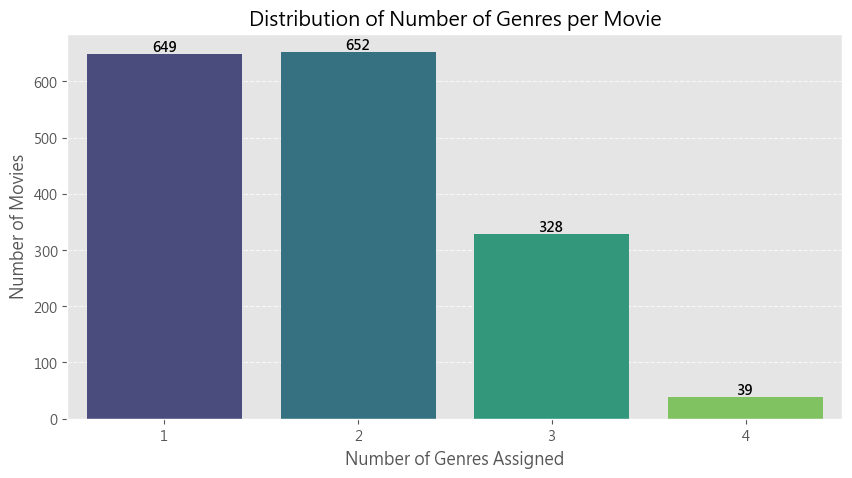

標籤數量統計摘要：
平均每部片標籤數: 1.85
最大標籤數: 4
最小標籤數: 1


In [180]:
# 1. 計算每部電影擁有幾個標籤
df_final['label_count'] = df_final['genre_list'].apply(len)

# 2. 統計各個數量的電影筆數
label_count_dist = df_final['label_count'].value_counts().sort_index()

# 3. 繪製長條圖
plt.figure(figsize=(10, 5))
sns.barplot(x=label_count_dist.index, y=label_count_dist.values, palette='viridis')

# 在長條圖上方顯示具體數字
for i, val in enumerate(label_count_dist.values):
    plt.text(i, val + 5, str(val), ha='center', fontweight='bold')

plt.title('Distribution of Number of Genres per Movie')
plt.xlabel('Number of Genres Assigned')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 輸出統計摘要
print("標籤數量統計摘要：")
print(f"平均每部片標籤數: {df_final['label_count'].mean():.2f}")
print(f"最大標籤數: {df_final['label_count'].max()}")
print(f"最小標籤數: {df_final['label_count'].min()}")

### 用 TF-IDF 訓練模型, 5-fold CV

In [181]:
# --- 步驟 1：數據準備 ---
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df_final['genre_list'])
target_names = mlb.classes_
X_raw = df_final['words']  # 使用原始文字，讓 Pipeline 處理 TF-IDF

# 定義 Jaccard Scorer (用於 cross_validate)
jaccard_samples_scorer = make_scorer(jaccard_score, average='samples')

# --- 步驟 2：定義模型組合 ---
# 包含 Logistic, Decision Tree, SVM, Random Forest
model_set = {
    'Logistic Regression': OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced')),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced'),
    'SVM (Linear)': OneVsRestClassifier(svm.SVC(kernel='linear', class_weight='balanced', probability=True)),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100)
}

results_summary = {}

# --- 步驟 3：循環訓練與 CV 分析 ---
for name, clf in model_set.items():
    print(f"模型名稱: {name} 5-Fold cv")
    
    # 建立管線：先做 TF-IDF 再訓練模型
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, min_df=2)),
        ('clf', clf)
    ])
    
    # A. 執行交叉驗證獲取穩定分數
    cv_results = cross_validate(
        pipeline, X_raw, y, 
        cv=5, 
        scoring={'jaccard': jaccard_samples_scorer}
    )
    avg_jaccard = np.mean(cv_results['test_jaccard'])
    
    # B. 使用 cross_val_predict 獲取所有樣本的預測結果，用來畫 report
    y_pred_cv = cross_val_predict(pipeline, X_raw, y, cv=5)
    
    # 儲存結果
    results_summary[name] = {
        'avg_jaccard': avg_jaccard,
        'report': classification_report(y, y_pred_cv, target_names=target_names, zero_division=0)
    }
    
    # 立即輸出該模型的結果
    print(f"Jaccard Score (交集/聯集): {avg_jaccard:.4f}")
    print(f"分類結果：")
    print(results_summary[name]['report'])
    print("-" * 60)

# --- 步驟 4：最終橫向對比 ---
print("\n" + "="*10 + "平均一部電影的 Jaccard Score (TP)/(TP+FP+FN)" + "="*10)
for name, res in results_summary.items():
    print(f"{name:20}: {res['avg_jaccard']:.4f}")

模型名稱: Logistic Regression 5-Fold cv
Jaccard Score (交集/聯集): 0.5590
分類結果：
              precision    recall  f1-score   support

          冒險       0.68      0.65      0.66       508
          劇情       0.68      0.68      0.68       609
          動作       0.76      0.74      0.75       648
          喜劇       0.63      0.58      0.61       468
          科幻       0.79      0.66      0.71       354
          驚悚       0.66      0.65      0.66       506

   micro avg       0.70      0.67      0.68      3093
   macro avg       0.70      0.66      0.68      3093
weighted avg       0.70      0.67      0.68      3093
 samples avg       0.67      0.68      0.64      3093

------------------------------------------------------------
模型名稱: Decision Tree 5-Fold cv
Jaccard Score (交集/聯集): 0.3553
分類結果：
              precision    recall  f1-score   support

          冒險       0.45      0.44      0.45       508
          劇情       0.46      0.46      0.46       609
          動作       0.54      0.48      0.

### 預覽模型預測狀況 (邏輯回歸)

In [182]:
# 1. 選擇模型名稱 (EX:'Logistic Regression')
analysis_model_name = 'Logistic Regression'

# 為了製作表格，我們需要重新跑一次該模型的預測（或從之前的 results_summary 抓取預測值）
# 這裡建議直接使用 cross_val_predict 拿到的全體預測 y_pred_cv
# 我們重新建立一個針對該模型的 pipeline 來獲取 y_pred_cv
best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=2)),
    ('clf', model_set[analysis_model_name])
])
y_pred_all = cross_val_predict(best_pipeline, X_raw, y, cv=5)

# 2. 還原標籤
truth_labels = mlb.inverse_transform(y)         # 全體真實標籤
pred_labels = mlb.inverse_transform(y_pred_all) # 全體 CV 預測標籤

# 3. 建立 DataFrame (這裏直接對應原本的 df_final)
comparison_df = pd.DataFrame({
    'Title': df_final['title'].values,
    'Truth': [list(t) for t in truth_labels],
    'Predict': [list(p) for p in pred_labels]
})

# 4. 新增計算欄位
# 計算交集 (共同擁有的標籤)
comparison_df['Intersection'] = comparison_df.apply(
    lambda x: list(set(x['Truth']) & set(x['Predict'])), axis=1
)

# 新增數量統計欄位
comparison_df['Truth_Count'] = comparison_df['Truth'].apply(len)
comparison_df['Predict_Count'] = comparison_df['Predict'].apply(len)

# 5. 定義預測狀況邏輯
def get_match_status(row):
    truth_set = set(row['Truth'])
    predict_set = set(row['Predict'])
    intersection_size = len(row['Intersection'])
    
    if truth_set == predict_set:
        return '成功'
    elif intersection_size > 0:
        return '部分成功'
    else:
        return '失敗'

comparison_df['Status'] = comparison_df.apply(get_match_status, axis=1)

# --- 顯示結果 ---
print(f"【{analysis_model_name}】電影標籤深度分析對照表 (基於 5-Fold CV)：")
# 隨機抽 10 筆來看看，這樣比 head(10) 更能看出模型在不同狀況下的表現
display(comparison_df.sample(10))

# 額外加碼：統計成功率
print("\n預測狀況統計：")
print(comparison_df['Status'].value_counts())

【Logistic Regression】電影標籤深度分析對照表 (基於 5-Fold CV)：


,Title,Truth,Predict,Intersection,Truth_Count,Predict_Count,Status
1152,移動城市致命引擎,"[冒險, 科幻]","[冒險, 動作, 科幻]","[科幻, 冒險]",2,3,部分成功
978,守護者,"[動作, 科幻]","[動作, 喜劇, 科幻]","[動作, 科幻]",2,3,部分成功
276,神鬼奇航幽靈海,"[冒險, 動作]","[冒險, 動作, 驚悚]","[動作, 冒險]",2,3,部分成功
415,捍衛任務,"[動作, 驚悚]","[動作, 驚悚]","[動作, 驚悚]",2,2,成功
1371,絕地騎士,"[冒險, 動作]","[劇情, 動作, 驚悚]",[動作],2,3,部分成功
1657,蝸牛少女回憶錄,"[劇情, 喜劇]",[劇情],[劇情],2,1,部分成功
1562,蜘蛛夫人,[動作],"[冒險, 科幻]",[],1,2,失敗
112,海綿寶寶電影版尋寶大冒險,"[冒險, 喜劇]","[冒險, 喜劇]","[喜劇, 冒險]",2,2,成功
1509,歡樂糖果屋,[喜劇],[喜劇],[喜劇],1,1,成功
1328,龍虎少年隊,"[動作, 喜劇]","[劇情, 喜劇, 驚悚]",[喜劇],2,3,部分成功



預測狀況統計：
Status
部分成功    880
成功      506
失敗      282
Name: count, dtype: int64


### 不同 label 數的電影，預測情形 (邏輯回歸) 
說明：                 (完全成功: 成功預測全部標籤, 部分成功: 多預測或少預測標籤, 完全失敗: 完全沒預測到任何 1 標籤)

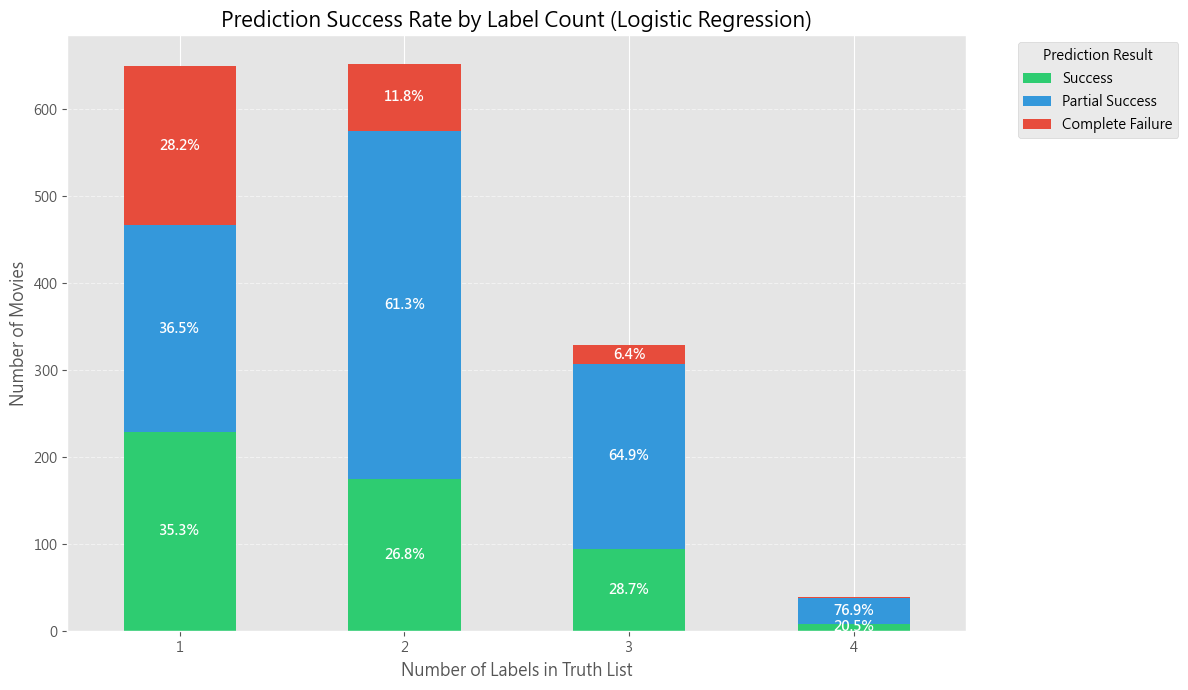

In [183]:
# 確保使用了正確的字體 (若在 Colab 繪製中文建議改為英文標籤或設定字體)
# 這裡先統一改為英文標籤以防圖表亂碼，或確保你環境支援中文
def categorize_success(row):
    if set(row['Truth']) == set(row['Predict']):
        return 'Success'           # 完全成功
    elif len(row['Intersection']) > 0:
        return 'Partial Success'   # 部分成功
    else:
        return 'Complete Failure'  # 失敗

comparison_df['Match_Type'] = comparison_df.apply(categorize_success, axis=1)

# 統計數據：依標籤數量分組
analysis_data = comparison_df.groupby(['Truth_Count', 'Match_Type']).size().unstack(fill_value=0)

# 為了確保顏色順序一致，手動排序 columns
cols = [c for c in ['Success', 'Partial Success', 'Complete Failure'] if c in analysis_data.columns]
analysis_data = analysis_data[cols]

# 繪製堆疊長條圖 (Success:綠, Partial:藍, Failure:紅)
colors = {'Success': '#2ecc71', 'Partial Success': '#3498db', 'Complete Failure': '#e74c3c'}
current_colors = [colors[c] for c in analysis_data.columns]

ax = analysis_data.plot(kind='bar', stacked=True, figsize=(12, 7), color=current_colors)

plt.title(f'Prediction Success Rate by Label Count ({analysis_model_name})', fontsize=15)
plt.xlabel('Number of Labels in Truth List', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.legend(title='Prediction Result', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 在圖上標註百分比
for i in range(len(analysis_data)):
    total = analysis_data.iloc[i].sum()
    y_offset = 0
    for col in analysis_data.columns:
        val = analysis_data.iloc[i][col]
        if val > 0:
            percentage = (val / total) * 100
            # 只有比例大於 5% 才顯示文字，避免太擠
            if percentage > 5:
                plt.text(i, y_offset + val/2, f'{percentage:.1f}%', 
                         ha='center', va='center', color='white', fontweight='bold')
            y_offset += val

plt.tight_layout()
plt.show()

### 單一 label 預測情形 (邏輯回歸)，N 個 2*2 矩陣 (True: 預測到該 label, False: 預測到其他 label)

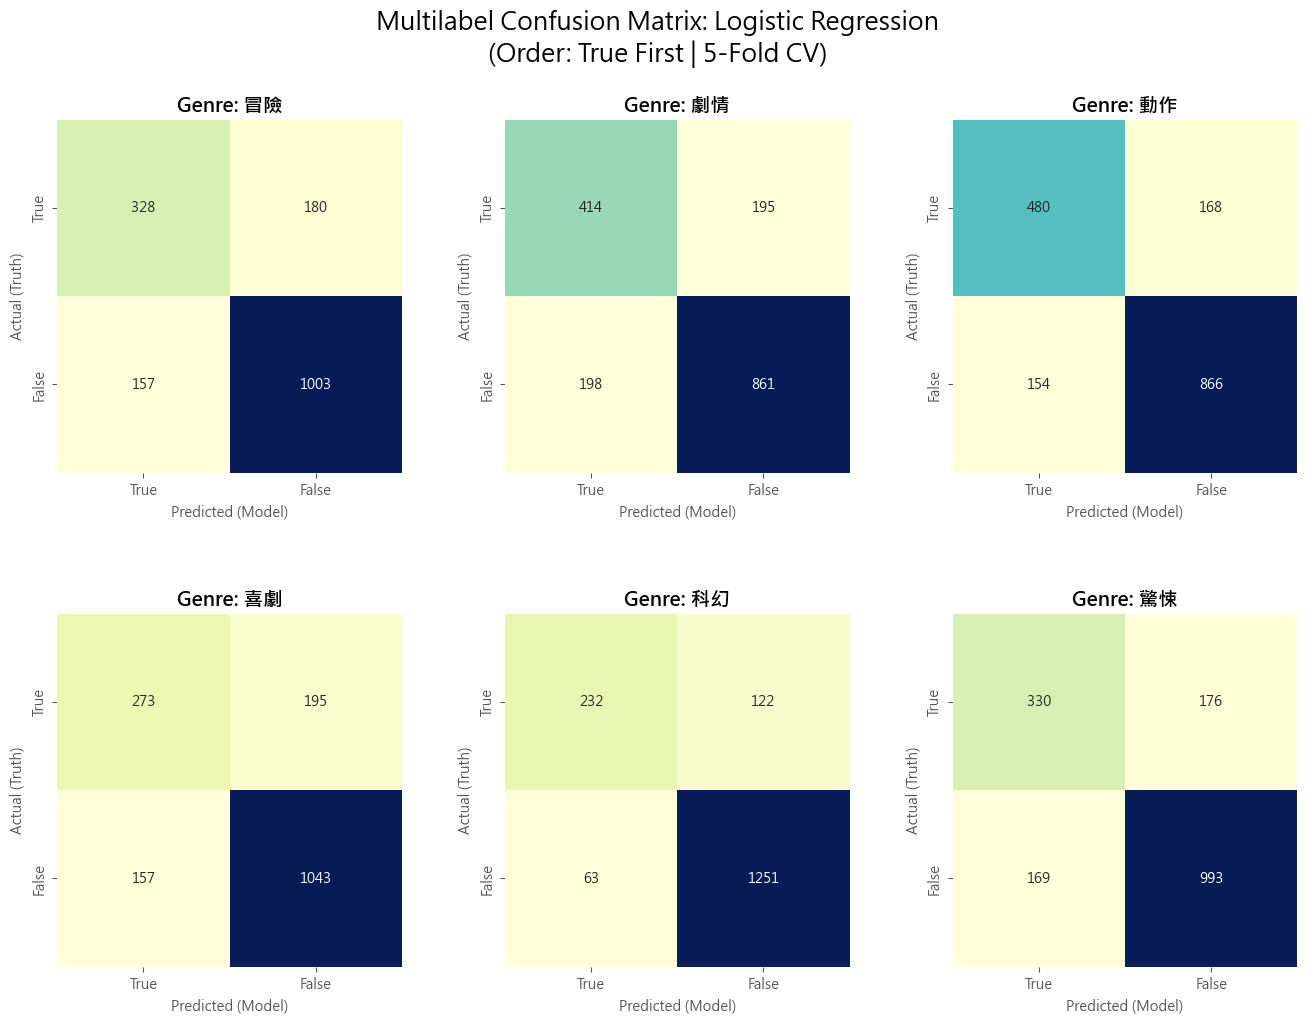

--- 【Logistic Regression】各類別詳細預測數據表 (True First) ---
類別         | TP         | FN         | FP         | TN        
---------------------------------------------------------------------------
冒險         |        328 |        180 |        157 |       1003
劇情         |        414 |        195 |        198 |        861
動作         |        480 |        168 |        154 |        866
喜劇         |        273 |        195 |        157 |       1043
科幻         |        232 |        122 |         63 |       1251
驚悚         |        330 |        176 |        169 |        993


In [184]:
# 1. 計算多標籤混淆矩陣
mcm = multilabel_confusion_matrix(y, y_pred_all)

# 2. 設定繪圖排列 (2x3)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 11))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 3. 遍歷每一個類別並翻轉矩陣順序
for i, (matrix, ax) in enumerate(zip(mcm, axes.flatten())):
    # 關鍵修正：將矩陣翻轉為 row: (True, False), col: (True, False)
    # 原本是 [[TN, FP], [FN, TP]] -> 翻轉後變為 [[TP, FN], [FP, TN]]
    flipped_matrix = matrix[::-1, ::-1]
    
    # 繪製熱點圖
    sns.heatmap(flipped_matrix, annot=True, fmt='d', cbar=False, ax=ax, cmap='YlGnBu',
                xticklabels=['True', 'False'], 
                yticklabels=['True', 'False'])
    
    label_name = target_names[i]
    ax.set_title(f'Genre: {label_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted (Model)', fontsize=10)
    ax.set_ylabel('Actual (Truth)', fontsize=10)

plt.suptitle(f'Multilabel Confusion Matrix: {analysis_model_name}\n(Order: True First | 5-Fold CV)', 
             fontsize=18, y=0.98)
plt.show()

# 4. 輸出量化指標摘要 (對應翻轉後的邏輯)
print(f"--- 【{analysis_model_name}】各類別詳細預測數據表 (True First) ---")
print(f"{'類別':<10} | {'TP':<10} | {'FN':<10} | {'FP':<10} | {'TN':<10}")
print("-" * 75)

for i, label in enumerate(target_names):
    # 因為矩陣已翻轉，ravel() 的順序變為 tp, fn, fp, tn
    tp, fn, fp, tn = mcm[i][::-1, ::-1].ravel()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"{label:<10} | {tp:>10} | {fn:>10} | {fp:>10} | {tn:>10}")

### RandomForest Recall 表現不佳，查看原因
原因：
因為 RF Tree 要超過半數同意才會給予 label，
因此在預測多類別的情況下，
很難有過半數同意給予 label，
導致預測時因為過於保守而不給 label。

In [191]:
# Random Forest

# 1. 選擇模型名稱 (確保名稱與你 model_set 中的 key 一致)
analysis_model_name = 'Random Forest'

# 重新建立針對 Random Forest 的 pipeline
# 這裡會使用 cross_val_predict 獲取所有樣本在 RF 下的 CV 預測結果
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, min_df=2)),
    ('clf', model_set[analysis_model_name])
])

print(f"正在執行 {analysis_model_name} 的 5-Fold Cross Validation 預測...")
y_pred_all_rf = cross_val_predict(rf_pipeline, X_raw, y, cv=5)

# 2. 還原標籤
truth_labels = mlb.inverse_transform(y)         # 全體真實標籤
pred_labels_rf = mlb.inverse_transform(y_pred_all_rf) # 全體 RF CV 預測標籤

# 3. 建立 DataFrame
comparison_df_rf = pd.DataFrame({
    'Title': df_final['title'].values,
    'Truth': [list(t) for t in truth_labels],
    'Predict': [list(p) for p in pred_labels_rf]
})

# 4. 新增計算欄位
# 計算交集
comparison_df_rf['Intersection'] = comparison_df_rf.apply(
    lambda x: list(set(x['Truth']) & set(x['Predict'])), axis=1
)

# 新增數量統計欄位
comparison_df_rf['Truth_Count'] = comparison_df_rf['Truth'].apply(len)
comparison_df_rf['Predict_Count'] = comparison_df_rf['Predict'].apply(len)

# 5. 定義預測狀況邏輯
def get_match_status(row):
    truth_set = set(row['Truth'])
    predict_set = set(row['Predict'])
    intersection_size = len(row['Intersection'])
    
    if truth_set == predict_set:
        return '成功'
    elif intersection_size > 0:
        return '部分成功'
    else:
        return '失敗'

comparison_df_rf['Status'] = comparison_df_rf.apply(get_match_status, axis=1)

# --- 顯示結果 ---
print(f"【{analysis_model_name}】電影標籤深度分析對照表 (基於 5-Fold CV)：")
# 隨機抽 10 筆
display(comparison_df_rf.sample(10))

# 統計預測狀況
print("\n預測狀況統計 (Random Forest)：")
status_counts = comparison_df_rf['Status'].value_counts()
print(status_counts)

正在執行 Random Forest 的 5-Fold Cross Validation 預測...
【Random Forest】電影標籤深度分析對照表 (基於 5-Fold CV)：


,Title,Truth,Predict,Intersection,Truth_Count,Predict_Count,Status
889,沙贊眾神之怒,"[動作, 喜劇]",[動作],[動作],2,1,部分成功
369,明日戰爭,"[冒險, 動作, 科幻]","[動作, 科幻]","[動作, 科幻]",3,2,部分成功
584,金剛,"[冒險, 劇情, 動作]",[],[],3,0,失敗
229,玩命關頭,"[動作, 驚悚]",[動作],[動作],2,1,部分成功
593,浴血任務,"[冒險, 動作, 驚悚]",[動作],[動作],3,1,部分成功
21,科學新娘,[科幻],[],[],1,0,失敗
1377,浩劫奇蹟,"[劇情, 驚悚]",[劇情],[劇情],2,1,部分成功
147,星際寶貝史迪奇,"[喜劇, 科幻]","[動作, 科幻]",[科幻],2,2,部分成功
1154,太空城,"[冒險, 動作, 科幻, 驚悚]",[],[],4,0,失敗
1170,攻殼機動隊,"[劇情, 動作, 科幻]",[動作],[動作],3,1,部分成功



預測狀況統計 (Random Forest)：
Status
失敗      965
部分成功    468
成功      235
Name: count, dtype: int64


### 不同 label 數的電影，預測情形 (隨機森林)

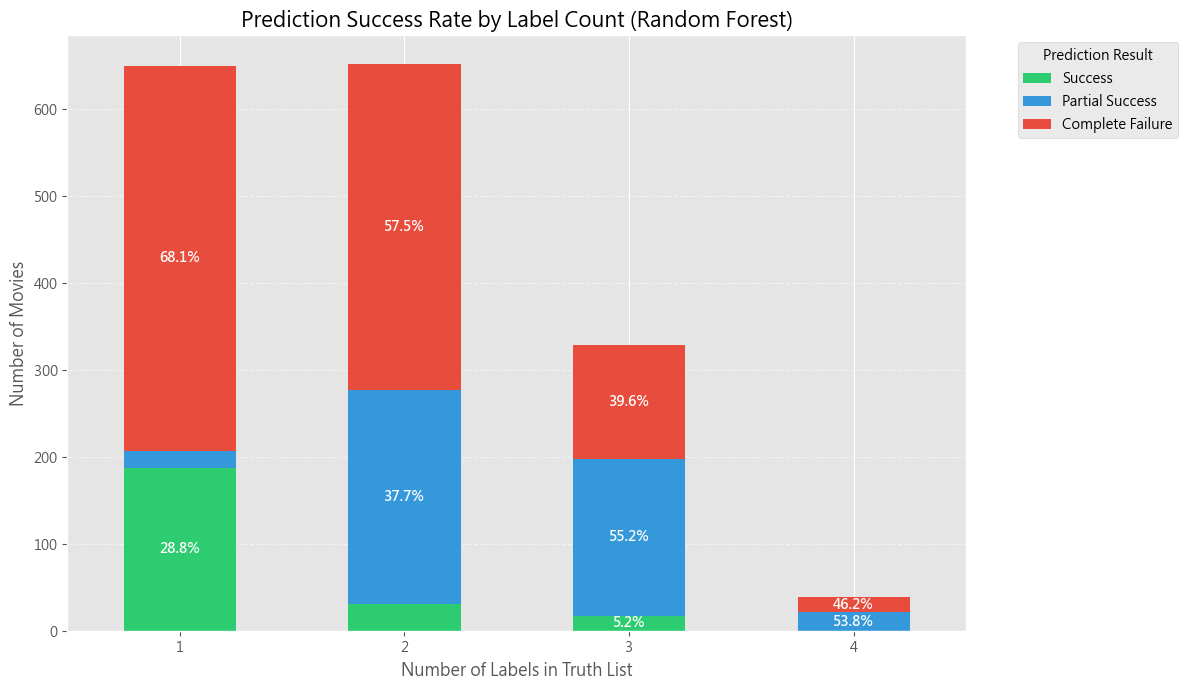

In [192]:
# 1. 確保使用 Random Forest 的數據結果
# 如果你之前的變數名稱是 comparison_df_rf，請確保這裡對應一致
df_to_plot = comparison_df_rf 

# 2. 定義成功類別 (與之前邏輯一致)
def categorize_success_rf(row):
    if set(row['Truth']) == set(row['Predict']):
        return 'Success'           # 完全成功
    elif len(row['Intersection']) > 0:
        return 'Partial Success'   # 部分成功
    else:
        return 'Complete Failure'  # 失敗

df_to_plot['Match_Type'] = df_to_plot.apply(categorize_success_rf, axis=1)

# 3. 統計數據：依標籤數量分組
analysis_data_rf = df_to_plot.groupby(['Truth_Count', 'Match_Type']).size().unstack(fill_value=0)

# 確保顏色順序與邏輯一致
cols = [c for c in ['Success', 'Partial Success', 'Complete Failure'] if c in analysis_data_rf.columns]
analysis_data_rf = analysis_data_rf[cols]

# 4. 繪製堆疊長條圖 (Success:綠, Partial:藍, Failure:紅)
colors = {'Success': '#2ecc71', 'Partial Success': '#3498db', 'Complete Failure': '#e74c3c'}
current_colors = [colors[c] for c in analysis_data_rf.columns]

ax = analysis_data_rf.plot(kind='bar', stacked=True, figsize=(12, 7), color=current_colors)

# 使用之前定義好的 analysis_model_name (應該是 'Random Forest')
plt.title(f'Prediction Success Rate by Label Count ({analysis_model_name})', fontsize=15)
plt.xlabel('Number of Labels in Truth List', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.legend(title='Prediction Result', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. 在圖上標註百分比
for i in range(len(analysis_data_rf)):
    total = analysis_data_rf.iloc[i].sum()
    y_offset = 0
    for col in analysis_data_rf.columns:
        val = analysis_data_rf.iloc[i][col]
        if val > 0:
            percentage = (val / total) * 100
            if percentage > 5:  # 只有比例大於 5% 才顯示文字
                plt.text(i, y_offset + val/2, f'{percentage:.1f}%', 
                         ha='center', va='center', color='white', fontweight='bold')
            y_offset += val

plt.tight_layout()
plt.show()

### 查看 (邏輯回歸) 預測每個類別影響最大的字詞 (正面:10 / 負面:10)

In [187]:
def plot_logistic_importance(pipeline, target_names, top_n=10):
    """
    分析 Logistic Regression Pipeline 中各類別影響力最大的字詞
    """
    # 1. 'tfidf' 取得詞彙名稱
    feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
    
    # 2. 'clf' 取得 OvR 分類器
    ovr_clf = pipeline.named_steps['clf']
    
    # 3. 遍歷每個電影標籤
    for i, label in enumerate(target_names):
        # 取得該類別對應的模型權重
        coef = ovr_clf.estimators_[i].coef_[0]
        
        # 整理成 DataFrame 方便排序
        coef_df = pd.DataFrame({'word': feature_names, 'coef': coef})
        
        # 正向影響 (Top N) 與 負向影響 (Bottom N)
        top_positive = coef_df.sort_values(by='coef', ascending=False).head(top_n)
        top_negative = coef_df.sort_values(by='coef', ascending=True).head(top_n)
        
        # 合併兩者 (正向、負向)
        plot_df = pd.concat([top_positive, top_negative.sort_values(by='coef', ascending=False)])

        # 開始繪圖
        plt.figure(figsize=(10, 6))
        # 正向：綠色，負向：紅色
        colors = ['darkseagreen' if c >= 0 else 'rosybrown' for c in plot_df['coef']]
        
        plt.barh(plot_df['word'], plot_df['coef'], color=colors)
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
        plt.gca().invert_yaxis()
        
        plt.title(f'影響「{label}」標籤的 Terms Top {top_n} (Logistic Regression)', size=15)
        plt.tight_layout()
        plt.show()

In [188]:
# 1. 將 0/1 矩陣轉回文字標籤列表
# 假設你現在想分析 Logistic 的結果，就用 y_pred_all；想看 RF 就用 y_pred_all_rf
readable_pred = [list(p) for p in mlb.inverse_transform(y_pred_all)]

# 2. 建立一個專門用來除錯的 DataFrame
# 我們直接用 df_final 作為基底，確保資料筆數完全對應
df_debug = df_final.copy()
df_debug['Predict'] = readable_pred

# 3. 為了方便分析原因，我們把「預測狀況」也加進去
def get_match_status(row):
    truth = set(row['genre_list'])
    predict = set(row['Predict'])
    if truth == predict: return '成功'
    return '部分成功' if len(truth & predict) > 0 else '失敗'

df_debug['Status'] = df_debug.apply(get_match_status, axis=1)

# 4. 篩選出「失敗」或「部分成功」的案例來檢查
# 觀察不完全預測的結果
error_cases = df_debug[df_debug['Status'] != 'Success'].copy()

# 5. 顯示結果 (包含原始 words、真實標籤、預測標籤)
print(f"目前共有 {len(error_cases)} 筆預測不完全正確的案例。")
display(error_cases[['title', 'words', 'genre_list', 'Predict', 'Status']].head(10))

目前共有 1668 筆預測不完全正確的案例。


,title,words,genre_list,Predict,Status
0,超級瑪利歐銀河電影版,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大喊 先過 這一關 碧姬 公主 則與 奇諾 比奧 迅速 打包 ...,"[喜劇, 冒險]","[冒險, 動作, 喜劇]",部分成功
1,阿凡達火與燼,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉及 蘇里 家人 一同 經歷 奮戰 傷痛 依然 展開 全新 冒...,"[科幻, 冒險]","[冒險, 動作]",部分成功
2,極限返航,極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到 這裡 原因 一無所知 記憶 逐漸 恢復 揭開 任務 真相 ...,"[科幻, 冒險]","[冒險, 動作, 科幻]",部分成功
3,降世神通最後的氣宗,降世 神通 最後 氣宗 意外 得知 一股 古老 力量 拯救 族群 免於 滅絕 夥伴 協助 踏上 一段 橫跨 世界 尋找 之旅 試圖 這股 力量 落入 歹...,"[動作, 冒險]","[冒險, 動作, 科幻]",部分成功
4,狸想世界,狸想 世界 熱愛 動物 梅寶 逮到 機會 藉由 科技 意識 進入 栩栩如生 機器 動物 身上 能夠 動物 溝通 能力 後院 揭開 連作 想不到 神祕 世界,"[科幻, 喜劇, 冒險]","[冒險, 喜劇, 科幻]",成功
5,狂鯊風暴,風暴 一場 毀滅性 颶風 沿海 小鎮 奮力 對抗 大自然 憤怒 鯊魚 襲擊 傾盆大雨 飛散 殘骸 伸手不見五指 黑暗 團結一心 勇敢 面對 致命 食者 ...,[驚悚],"[動作, 驚悚]",部分成功
6,凸槌拍檔,凸槌 拍檔 這部 口味 尺度 炸裂 喜劇 行銷 專員 布萊德 伊萊 放手一搏 大膽 提案 全方位 包覆 保險套 品牌 冠名 贊助 世界盃 沒想到 兩人 ...,"[喜劇, 動作, 冒險]",[喜劇],部分成功
7,天眼浩劫,天眼 浩劫 一名 隱居 蘇格蘭 偏遠 小島 男子 遠離 現代 社會 外界 接觸 拯救 一名 落海 少女 引發 一連串 危機 導致 住處 小島 遭到 襲擊...,"[動作, 驚悚]","[劇情, 動作, 驚悚]",部分成功
8,天劫倒數大遷徙,天劫 倒數 遷徙 倖存 蓋瑞提 一家 離開 安全 格陵蘭島 避難所 踏上 危險 旅程 穿越 歐洲 滿目瘡痍 冰凍 荒原 尋找 家園,"[冒險, 驚悚, 科幻]","[冒險, 動作]",部分成功
9,荒島囚救,荒島 囚救 兩個 同事 飛機 墜毀 成為 僅存 生還者 困在 一座 荒島 拋開 過去 恩怨 同心協力 求生 已經 不在 辦公室 裡了 這部 原創 黑色 ...,"[驚悚, 喜劇]",[],失敗


### 挑選預測結果為：[不完全預測] 的電影

In [189]:
# 看看所有被預測為「動作」但實際不是動作的電影，它們的 words 裡共同出現了什麼詞？
fp_action = error_cases[
    (error_cases['Predict'].apply(lambda x: '動作' in x)) & 
    (error_cases['genre_list'].apply(lambda x: '動作' not in x))
]

print("被誤判為動作片的字詞統計：")
# 簡單看一下這些誤判案例的 words 前 20 筆
display(fp_action[['title', 'words', 'genre_list', 'Predict']].head(10))

被誤判為動作片的字詞統計：


,title,words,genre_list,Predict
0,超級瑪利歐銀河電影版,超級 瑪利 銀河 電影版 面對 反派 勢力 再度 崛起 瑪利 蘑菇 王國 挺身而出 迎戰 大喊 先過 這一關 碧姬 公主 則與 奇諾 比奧 迅速 打包 ...,"[喜劇, 冒險]","[冒險, 動作, 喜劇]"
1,阿凡達火與燼,阿凡 達火 這次 故事 敘述 人類 歸化 納美族 並當 首領 傑克 妻子 納美 戰士 奈蒂莉及 蘇里 家人 一同 經歷 奮戰 傷痛 依然 展開 全新 冒...,"[科幻, 冒險]","[冒險, 動作]"
2,極限返航,極限 返航 科學 老師 萊倫 格雷斯 一艘 距離 地球 好幾 光年 太空船 醒來 身分 來到 這裡 原因 一無所知 記憶 逐漸 恢復 揭開 任務 真相 ...,"[科幻, 冒險]","[冒險, 動作, 科幻]"
5,狂鯊風暴,風暴 一場 毀滅性 颶風 沿海 小鎮 奮力 對抗 大自然 憤怒 鯊魚 襲擊 傾盆大雨 飛散 殘骸 伸手不見五指 黑暗 團結一心 勇敢 面對 致命 食者 ...,[驚悚],"[動作, 驚悚]"
8,天劫倒數大遷徙,天劫 倒數 遷徙 倖存 蓋瑞提 一家 離開 安全 格陵蘭島 避難所 踏上 危險 旅程 穿越 歐洲 滿目瘡痍 冰凍 荒原 尋找 家園,"[冒險, 驚悚, 科幻]","[冒險, 動作]"
12,犯罪,犯罪 陽光 炙烤 洛杉磯 公路 接連 得手 一樁 精密 計算 搶案 滴水不漏 手法 警方 束手無策 一名 獨來獨往 警探 馬克 魯法洛 緊咬 誓要 將他...,[驚悚],"[動作, 驚悚]"
15,嗜殺路人丙,路人 系列 殘酷 章節 瑪雅 蒙面 殺手 發生衝突 發現 擺脫 噩夢 唯一 方法 進入 噩夢 之中,[驚悚],"[動作, 驚悚]"
17,動物方城市,動物 城市 警官 哈茱蒂 尼克 這次 搭檔 追蹤 一隻 神祕 爬蟲類 蜿蜒 蹤跡 到來 這座 哺乳類 為主 大城市 天翻地覆 破案 茱蒂 尼克 城市 意...,"[冒險, 喜劇]","[動作, 驚悚]"
36,星際效應,星際 效應 地球 毀滅 一群 探險家 扛起 人類史上 重要 任務 越過 已知 銀河 星際 尋找 人類 未來 可能性 未來 地球 劇烈 氣候變化 影響 農...,"[冒險, 劇情, 科幻]","[冒險, 動作, 科幻]"
39,度,一場 突如其來 行車 糾紛 兒子 命在旦夕 盛怒 父親 踏上 煎熬 黑暗 復仇,"[驚悚, 劇情]","[劇情, 動作, 驚悚]"


### 挑選一篇電影，觀察他的字詞

In [190]:
# 1. 找到標題為「動物方城市」的那一筆資料
# 我們直接從 df_debug 或 df_final 抓取
zootopia_words = df_final[df_final['title'] == '動物方城市']['words'].values[0]

# 2. 完整輸出內容
print(f"【動物方城市】words：\n")
print(zootopia_words)

【動物方城市】words：

動物 城市 警官 哈茱蒂 尼克 這次 搭檔 追蹤 一隻 神祕 爬蟲類 蜿蜒 蹤跡 到來 這座 哺乳類 為主 大城市 天翻地覆 破案 茱蒂 尼克 城市 意想不到 地點 進行 臥底 辦案 過程 碰壁 案件 影響 層面 更是 盤根錯節 背後 是否 深藏不露 藏鏡 操控 兩人 搭檔 關係 面臨 前所未有 考驗


# 主題分類

- 資料前處理
- LDA模型分析
- Guided LDA模型分析
- 比較千喜年前後的主題分布

In [2]:
movies = pd.read_csv("data/movies_label.csv")  # 匯資料
print(f"number of posts: {movies.shape[0]}")
movies.head(3)

number of posts: 2000


,adult,backdrop_path,id,original_language,original_title,overview,popularity,poster_path,release_date,title,video,vote_average,vote_count,genre_label
0,False,/kxQiIJ4gVcD3K6o14MJ72p5yRcE.jpg,1226863,en,The Super Mario Galaxy Movie,面對反派勢力再度崛起，瑪利歐也為蘑菇王國挺身而出迎戰，大喊：「先過我這一關！」碧姬公主則與奇諾比奧迅速打包啟程，前往銀河尋找羅潔塔公主；一群色彩繽紛又可...,828.4621,/yAI5H1T6qzFPHml5PFC7rthjRU3.jpg,2026-04-01,超級瑪利歐銀河電影版,False,6.800,521,家庭、喜劇、冒險、奇幻、動畫
1,False,/1x9e0qWonw634NhIsRdvnneeqvN.jpg,1523145,ru,Твоё сердце будет разбито,NaN,434.1481,/iGpMm603GUKH2SiXB2S5m4sZ17t.jpg,2026-03-26,Твоё сердце будет разбито,False,7.094,65,愛情、劇情
2,False,/u8DU5fkLoM5tTRukzPC31oGPxaQ.jpg,83533,en,Avatar: Fire and Ash,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里、妻子納美戰士奈蒂莉及蘇里的家人一同，在經歷奮戰與傷痛後，依然必須展開全新冒險，也將面臨新登場反派的威脅。,329.6580,/wCqdYTvQSNITnTUrJ5xwzSMrAB1.jpg,2025-12-17,阿凡達：火與燼,False,7.372,2645,科幻、冒險、奇幻


### 資料前處理

In [3]:
# 移除必要欄位缺失資料
movies = movies.dropna(subset=['overview', 'title', 'genre_label'], how='any').copy()

# 只保留中文字
movies['overview'] = movies['overview'].apply(lambda x: re.sub(r"[^\u4e00-\u9fa5]+", "", str(x)))
movies['title'] = movies['title'].apply(lambda x: re.sub(r"[^\u4e00-\u9fa5]+", "", str(x)))

# 合併 title + overview 作為分析文本
movies['content'] = movies['title'] + movies['overview']

# 拆解多標籤 genre
movies['genre_list'] = movies['genre_label'].str.split('、')

print(f"清理後資料筆數：{movies.shape[0]}")
display(movies[['title', 'overview', 'genre_label', 'genre_list']].head(3))

清理後資料筆數：1770


,title,overview,genre_label,genre_list
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,家庭、喜劇、冒險、奇幻、動畫,"[家庭, 喜劇, 冒險, 奇幻, 動畫]"
2,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,科幻、冒險、奇幻,"[科幻, 冒險, 奇幻]"
3,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,科幻、冒險,"[科幻, 冒險]"


### 斷詞與停用字

In [4]:
jieba.set_dictionary(JIEBA_DICT_PATH)

# 讀取原本停用字
with open(STOPWORDS_PATH, encoding='utf-8') as f:
    stopWords = [line.strip() for line in f.readlines()]

# 電影介紹常見但對主題辨識幫助不大的字
movie_stopwords = [
    '成為', '發現', '展開', '故事'
    '最後', '一名', '一位', '一場', '兩人', '一群', '一起',
    '電影', '本片', '飾演',
    '之後', '之間', '決定', '面對', '開始', '前往', '來到',
    '所有', '自己', '他們', '她們'
]

stopWords = list(set(stopWords + movie_stopwords))
print('停用字總數：', len(stopWords))
# 自動加入常見電影專有名詞（角色名、人名、地名）
# 先初步斷詞一次
raw_docs = []

for text in movies['content']:
    words = [
        w for w in jieba.cut(str(text), cut_all=False)
        if w not in stopWords and len(w) > 0
    ]
    raw_docs.append(words)

PHRASE_MIN_COUNT = 3
PHRASE_THRESHOLD = 5

# 找常見連續詞
bigram = Phrases(raw_docs, min_count=PHRASE_MIN_COUNT, threshold=PHRASE_THRESHOLD)
bigram_model = Phraser(bigram)
bigram_docs = list(bigram_model[raw_docs])

trigram = Phrases(bigram_docs, min_count=PHRASE_MIN_COUNT, threshold=PHRASE_THRESHOLD)
trigram_model = Phraser(trigram)
trigram_docs = list(trigram_model[bigram_docs])

fourgram = Phrases(trigram_docs, min_count=PHRASE_MIN_COUNT, threshold=PHRASE_THRESHOLD)
fourgram_model = Phraser(fourgram)
fourgram_docs = list(fourgram_model[trigram_docs])

# 加入 jieba 字典
new_words = set()

for doc in bigram_model[raw_docs]:
    for token in doc:
        if "_" in token:
            token = token.replace("_", "")
            if len(token) >= 2:
                new_words.add(token)

for w in new_words:
    jieba.add_word(w, freq=200000)

print("自動加入詞數：", len(new_words))
print(list(new_words)[:50])

# 斷詞

def get_tokens(text):
    seg_list = jieba.cut(str(text), cut_all=False)
    return [w for w in seg_list if w not in stopWords and len(w) > 1]

movies['words'] = movies['content'].apply(get_tokens)
movies['words_str'] = movies['words'].map(' '.join)

# 移除空文件
movies = movies[movies['words'].apply(len) > 0].copy()

print(f"斷詞後資料筆數：{movies.shape[0]}")
display(movies[['title', 'overview', 'words', 'genre_list']].head(3))

Building prefix dict from d:\NSYSU\社媒\SMA_2026S-main\SMA_2026S-main\project2_movie\dict\dict.txt.big ...
Loading model from cache C:\Users\User\AppData\Local\Temp\jieba.u3a73f118e739b0d766e06d5bd50f6493.cache


停用字總數： 1231


Loading model cost 0.715 seconds.
Prefix dict has been built successfully.


自動加入詞數： 754
['禁忌世代', '一次偶然', '奧斯卡最佳影片', '庫倫家族', '世界各國', '好朋友', '暮光之城', '致命病毒', '夢中', '殺人遊戲', '加入行列', '羅伯派', '年輕女孩', '銀河中', '墜入愛河', '令人聞風喪膽', '影史最', '柯里昂', '驅使下', '歐兄弟', '一次意外', '有史以來最', '致命危機', '水晶骷髏', '邪惡計畫', '巴斯光年', '凱妮絲', '最佳剪輯', '吸血鬼公爵', '最黑暗', '現代社會', '心魔', '前所未有危機', '女服務生', '女子高校', '尖峰時刻', '擁有強大', '新朋友', '故事描述', '卡特教頭', '難以解釋', '邪惡巫師', '過去陰影', '平靜生活', '綠巨人浩克', '付出代價', '經歷一連串', '漫威宇宙', '事件改編', '世界和平']
斷詞後資料筆數：1770


,title,overview,words,genre_list
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,"[超級瑪利, 銀河, 電影版, 反派, 勢力, 再度, 崛起, 瑪利歐, 蘑菇, 王國, 挺身而出, 迎戰, 大喊, 先過, 這一關, 碧姬, 公主, ...","[家庭, 喜劇, 冒險, 奇幻, 動畫]"
2,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,"[阿凡, 達火, 這次, 故事敘述, 人類, 歸化, 納美族, 並當, 首領, 傑克, 蘇里, 妻子, 納美, 戰士, 奈蒂莉, 蘇里, 家人, 一同,...","[科幻, 冒險, 奇幻]"
3,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,"[極限, 返航, 科學, 老師, 萊倫, 格雷斯, 一艘, 距離, 地球, 好幾, 光年, 太空船, 醒來, 身分, 這裡, 原因, 一無所知, 記憶,...","[科幻, 冒險]"


### 類別數量統計

所有類別的數量：
genre_list
動作      648
劇情      609
冒險      508
驚悚      506
喜劇      468
科幻      354
奇幻      295
犯罪      270
家庭      267
恐怖      245
愛情      238
動畫      234
懸疑      143
歷史       60
戰爭       60
音樂       40
西部       23
紀錄       10
電視電影      5
Name: count, dtype: int64


d:\NSYSU\社媒\SMA_2026S-main\SMA_2026S-main\dm\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
d:\NSYSU\社媒\SMA_2026S-main\SMA_2026S-main\dm\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
d:\NSYSU\社媒\SMA_2026S-main\SMA_2026S-main\dm\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


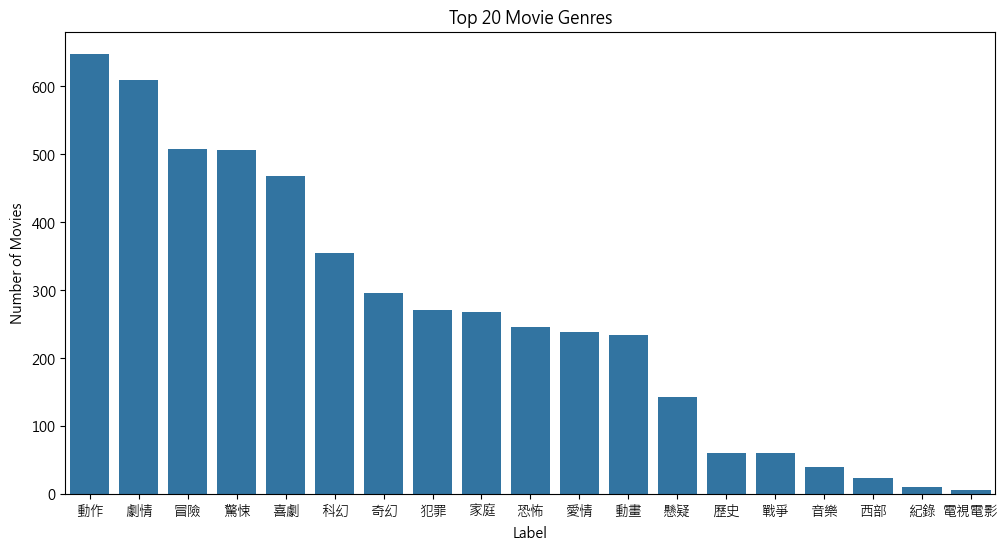

In [5]:
df_genre_exploded = movies.explode('genre_list')
all_genre_counts = df_genre_exploded['genre_list'].value_counts()

print("所有類別的數量：")
print(all_genre_counts)

plt.figure(figsize=(12, 6))
sns.barplot(x=all_genre_counts.head(20).index, y=all_genre_counts.head(20).values)
plt.title('Top 20 Movie Genres')
plt.xlabel('Label')
plt.ylabel('Number of Movies')
plt.xticks(rotation=0, ha='center')
plt.show()

### 建立 LDA 資料、訓練模型、評估模型、視覺化

In [6]:
# 把每部電影的斷詞結果整理成 list
# 建立字典，也就是把每個詞編號
# 把每篇電影介紹轉成 BOW 格式
def build_lda_inputs(df, text_col='words'):
    """把 token list 建成 gensim dictionary 與 corpus。"""
    docs = df[text_col].tolist()

    dictionary = Dictionary(docs)
    dictionary.filter_extremes(
        no_below=NO_BELOW,
        no_above=NO_ABOVE,
        keep_n=KEEP_N
    )

    corpus = [dictionary.doc2bow(doc) for doc in docs]

    print('文件數：', len(docs))
    print('字典：', dictionary)
    print('第一篇文件斷詞前 30 個：')
    print(docs[0][:30])
    print('第一篇 BOW 前 10 個：')
    print(corpus[0][:10])

    return docs, dictionary, corpus

In [7]:
# 訓練 LDA 模型
def train_lda(corpus, dictionary, num_topics):
    """訓練單一 LDA 模型。"""
    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=RANDOM_STATE,
        passes=PASSES,
        iterations=ITERATIONS,
        alpha='auto',
        eta='auto'
    )
    return model

In [8]:
# 評估 LDA 模型
def evaluate_lda(model, corpus, docs, dictionary):
    """回傳 perplexity 與 NPMI。"""
    log_perplexity = model.log_perplexity(corpus)
    perplexity = np.exp2(-log_perplexity)

    npmi_model = CoherenceModel(
        model=model,
        texts=docs,
        dictionary=dictionary,
        coherence='c_npmi'
    )
    npmi = npmi_model.get_coherence()
    npmi_per_topic = npmi_model.get_coherence_per_topic()

    return perplexity, npmi, npmi_per_topic

In [9]:
# 自動測試不同 topic 數，選 NPMI 最佳
def search_best_topic_num(docs, dictionary, corpus, topic_range=TOPIC_RANGE, exp_name='Experiment'):
    """測試不同 topic 數，並回傳結果表、模型集合、最佳 topic 數。"""
    t0 = time.time()

    result = {
        'topic_num': [],
        'perplexity': [],
        'npmi': []
    }
    model_set = {}

    for topic_num in topic_range:
        print(f'{exp_name} 正在訓練 topic_num = {topic_num}')

        model = train_lda(corpus, dictionary, topic_num)
        perplexity, npmi, _ = evaluate_lda(model, corpus, docs, dictionary)

        result['topic_num'].append(topic_num)
        result['perplexity'].append(perplexity)
        result['npmi'].append(npmi)
        model_set[topic_num] = model

    result_df = pd.DataFrame(result)
    best_topic_num = int(result_df.loc[result_df['npmi'].idxmax(), 'topic_num'])

    print(f'{exp_name} 花費時間：{time.time() - t0:.2f} 秒')
    print(f'{exp_name} NPMI 最高的主題數：{best_topic_num}')
    display(result_df.sort_values('npmi', ascending=False))

    return result_df, model_set, best_topic_num

In [10]:
# 畫 Perplexity 和 NPMI 趨勢圖
def plot_topic_metrics(result_df, exp_name='Experiment'):
    """畫出 Perplexity 與 NPMI 趨勢圖。"""
    plt.figure(figsize=(8, 5))
    plt.plot(result_df['topic_num'], result_df['perplexity'], marker='o')
    plt.title(f'{exp_name}: Topic Number vs Perplexity')
    plt.xlabel('Number of Topics')
    plt.ylabel('Perplexity')
    plt.xticks(result_df['topic_num'])
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(result_df['topic_num'], result_df['npmi'], marker='o')
    plt.title(f'{exp_name}: Topic Number vs NPMI')
    plt.xlabel('Number of Topics')
    plt.ylabel('NPMI Coherence')
    plt.xticks(result_df['topic_num'])
    plt.show()

In [11]:
# LDA 模型做成互動式視覺化
def make_pyldavis(model, corpus, dictionary):
    """產生 pyLDAvis 視覺化。"""
    pyLDAvis.enable_notebook()
    vis = pyLDAvis.gensim_models.prepare(
        model,
        corpus,
        dictionary,
        sort_topics=False
    )
    return vis

In [12]:
 # 幫每部電影指定「最主要主題」
def assign_main_topic(df, model, corpus):
    """幫每部電影找出主要 topic 與 topic probability。"""
    lda_result = []

    for bow in corpus:
        topic_dist = model.get_document_topics(bow, minimum_probability=0)
        topic_dist = sorted(topic_dist, key=lambda x: x[1], reverse=True)
        lda_result.append(topic_dist[0])

    df_result = df.copy()
    df_result['lda_topic'] = [x[0] for x in lda_result]
    df_result['lda_topic_prob'] = [x[1] for x in lda_result]

    return df_result

In [13]:
# 列出每個 topic 最重要的字
def show_topic_keywords(model, num_words=15):
    """整理每個 topic 的代表字。"""
    rows = []
    for topic_id in range(model.num_topics):
        words = model.show_topic(topic_id, topn=num_words)
        rows.append({
            'topic': topic_id,
            'keywords': '、'.join([w for w, p in words])
        })
    topic_keywords_df = pd.DataFrame(rows)
    display(topic_keywords_df)
    return topic_keywords_df

In [14]:
 # 找每個 topic 最具代表性的電影
def show_representative_movies(df_result, topic_num, top_n=5, topic_names=None):
    """查看每個 topic 最具代表性的電影。"""
    for topic_id in range(topic_num):
        topic_label = topic_names.get(topic_id, f'Topic {topic_id}') if topic_names else f'Topic {topic_id}'
        print('' + '=' * 70)
        print(f'{topic_label} 代表電影')
        display(
            df_result[df_result['lda_topic'] == topic_id]
            .sort_values('lda_topic_prob', ascending=False)
            [['title', 'overview', 'genre_list', 'lda_topic_prob']]
            .head(top_n)
        )

### 全部電影資料 LDA

全部電影筆數： 1770


,title,overview,words,genre_list,release_date
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,"[超級瑪利, 銀河, 電影版, 反派, 勢力, 再度, 崛起, 瑪利歐, 蘑菇, 王國, 挺身而出, 迎戰, 大喊, 先過, 這一關, 碧姬, 公主, ...","[家庭, 喜劇, 冒險, 奇幻, 動畫]",2026-04-01
2,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,"[阿凡, 達火, 這次, 故事敘述, 人類, 歸化, 納美族, 並當, 首領, 傑克, 蘇里, 妻子, 納美, 戰士, 奈蒂莉, 蘇里, 家人, 一同,...","[科幻, 冒險, 奇幻]",2025-12-17
3,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,"[極限, 返航, 科學, 老師, 萊倫, 格雷斯, 一艘, 距離, 地球, 好幾, 光年, 太空船, 醒來, 身分, 這裡, 原因, 一無所知, 記憶,...","[科幻, 冒險]",2026-03-15


文件數： 1770
字典： Dictionary<3668 unique tokens: ['公主', '再度', '勢力', '反派', '可愛']...>
第一篇文件斷詞前 30 個：
['超級瑪利', '銀河', '電影版', '反派', '勢力', '再度', '崛起', '瑪利歐', '蘑菇', '王國', '挺身而出', '迎戰', '大喊', '先過', '這一關', '碧姬', '公主', '則與', '奇諾', '比奧', '迅速', '打包', '啟程', '銀河', '尋找', '潔塔', '公主', '色彩繽紛', '可愛', '加入行列']
第一篇 BOW 前 10 個：
[(0, 2), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1)]
Experiment B 正在訓練 topic_num = 2
Experiment B 正在訓練 topic_num = 3
Experiment B 正在訓練 topic_num = 4
Experiment B 正在訓練 topic_num = 5
Experiment B 正在訓練 topic_num = 6
Experiment B 正在訓練 topic_num = 7
Experiment B 正在訓練 topic_num = 8
Experiment B 正在訓練 topic_num = 9
Experiment B 正在訓練 topic_num = 10
Experiment B 花費時間：351.92 秒
Experiment B NPMI 最高的主題數：3


,topic_num,perplexity,npmi
1,3,235.679932,-0.090243
0,2,231.470013,-0.121512
2,4,242.817731,-0.129754
3,5,249.073508,-0.134502
4,6,255.241942,-0.162736
5,7,260.855225,-0.172272
7,9,272.617770,-0.192823
8,10,277.818515,-0.198214
6,8,266.684585,-0.199970


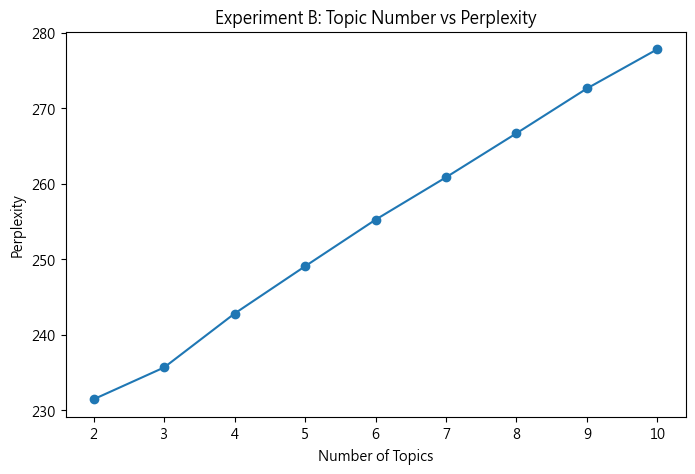

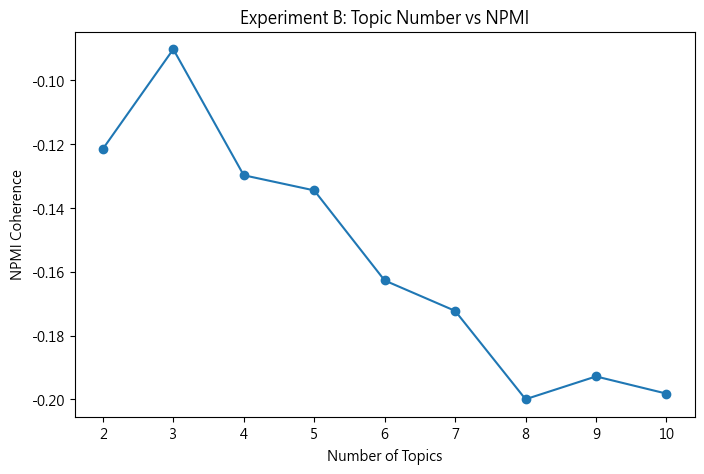

最佳模型主題代表字：
[(0,
  '0.007*"生活" + 0.006*"故事" + 0.004*"殺手" + 0.003*"最後" + 0.003*"美國" + 0.003*"世界" '
  '+ 0.002*"任務" + 0.002*"威廉" + 0.002*"法蘭克" + 0.002*"導演"'),
 (1,
  '0.011*"人類" + 0.008*"世界" + 0.008*"地球" + 0.005*"任務" + 0.003*"未來" + 0.003*"美國" '
  '+ 0.003*"最後" + 0.003*"找到" + 0.003*"故事" + 0.003*"機器人"'),
 (2,
  '0.005*"生活" + 0.004*"父親" + 0.004*"美國" + 0.003*"女兒" + 0.003*"妻子" + 0.003*"發生" '
  '+ 0.003*"意外" + 0.003*"小鎮" + 0.003*"人生" + 0.003*"家庭"')]


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.063787  0.058179       1        1  26.265392
1     -0.102337  0.010422       2        1  32.773165
2      0.038550 -0.068600       3        1  40.961443, topic_info=    Term        Freq       Total Category  logprob  loglift
15    人類  232.000000  232.000000  Default  30.0000  30.0000
39    地球  152.000000  152.000000  Default  29.0000  29.0000
322   殺手   88.000000   88.000000  Default  28.0000  28.0000
63    世界  253.000000  253.000000  Default  27.0000  27.0000
447   生活  255.000000  255.000000  Default  26.0000  26.0000
..   ...         ...         ...      ...      ...      ...
982   陷入   46.883144   81.081898   Topic3  -6.2415   0.3447
506   家族   46.616426   81.014643   Topic3  -6.2472   0.3399
17    傑克   46.415780   84.024625   Topic3  -6.2515   0.2991
63    世界   53.728005  253.751032   Topic3  -6.1053  -0.6599
78    最後   48.244681  164.587428   Topic3  -6.2129  -0.3346

[260 rows x 6 columns], token_table=      Topic      Freq Term
term                      
2637      3  0.952068   一棟
436       1  0.248881   丈夫
436       2  0.049776   丈夫
436       3  0.696867   丈夫
63        1  0.169457   世界
...     ...       ...  ...
220       3  0.893170   麥可
842       1  0.019953   黑幫
842       3  0.957721   黑幫
3239      1  0.731784   龐德
3239      2  0.235216   龐德

[446 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3])

In [15]:
df_topic_b = movies[
    ['title', 'overview', 'words', 'genre_list', 'release_date']
].copy()

print('全部電影筆數：', len(df_topic_b))
display(df_topic_b.head(3))

# 建立實驗 B LDA 輸入
docs_b, dictionary_b, corpus_b = build_lda_inputs(df_topic_b)

# 測試 topic 數 2~10
result_b, model_set_b, best_topic_num_b = search_best_topic_num(
    docs_b,
    dictionary_b,
    corpus_b,
    topic_range=TOPIC_RANGE,
    exp_name='Experiment B'
)

plot_topic_metrics(result_b, exp_name='Experiment B')

# 取出實驗 B NPMI 最佳模型
best_model_b = model_set_b[best_topic_num_b]
print('最佳模型主題代表字：')
pprint(best_model_b.print_topics(num_words=10))

# 實驗 B pyLDAvis
vis_b = make_pyldavis(best_model_b, corpus_b, dictionary_b)
vis_b

In [16]:
print('全部電影資料不同 topic 數評估結果：')
display(result_b)

print('依照 NPMI 自動選出的最佳 topic 數：', best_topic_num_b)

全部電影資料不同 topic 數評估結果：


,topic_num,perplexity,npmi
0,2,231.470013,-0.121512
1,3,235.679932,-0.090243
2,4,242.817731,-0.129754
3,5,249.073508,-0.134502
4,6,255.241942,-0.162736
5,7,260.855225,-0.172272
6,8,266.684585,-0.199970
7,9,272.617770,-0.192823
8,10,277.818515,-0.198214


依照 NPMI 自動選出的最佳 topic 數： 3


In [17]:
FINAL_TOPIC_NUM = 3

final_model = model_set_b.get(FINAL_TOPIC_NUM)

# 若前面沒有訓練過 topic=2，則重新訓練
if final_model is None:
    final_model = train_lda(corpus_b, dictionary_b, FINAL_TOPIC_NUM)

final_perplexity, final_npmi, final_npmi_per_topic = evaluate_lda(
    final_model,
    corpus_b,
    docs_b,
    dictionary_b
)

print('Final Model：Experiment B，全部電影資料，topic=3')
print('Perplexity：', final_perplexity)
print('NPMI：', final_npmi)
print('每個 topic 的 NPMI：')
print(final_npmi_per_topic)

Final Model：Experiment B，全部電影資料，topic=3
Perplexity： 235.67908459523886
NPMI： -0.09024263746443449
每個 topic 的 NPMI：
[-0.12906836520878656, -0.08584907890414441, -0.055810468280372484]


,topic,keywords
0,0,生活、故事、殺手、最後、美國、世界、任務、威廉、法蘭克、導演、發生、年輕、英國、神秘、犯罪
1,1,人類、世界、地球、任務、未來、美國、最後、找到、故事、機器人、拯救、冒險、意外、尋找、宇宙
2,2,生活、父親、美國、女兒、妻子、發生、意外、小鎮、人生、家庭、過去、找到、無法、母親、逐漸


,topic_name,keywords
0,警匪犯罪、動作片,生活、故事、殺手、最後、美國、世界、任務、威廉、法蘭克、導演、發生、年輕、英國、神秘、犯罪
1,科幻、奇幻、冒險片,人類、世界、地球、任務、未來、美國、最後、找到、故事、機器人、拯救、冒險、意外、尋找、宇宙
2,家庭人生、劇情片,生活、父親、美國、女兒、妻子、發生、意外、小鎮、人生、家庭、過去、找到、無法、母親、逐漸


,title,overview,genre_list,lda_topic,lda_topic_prob
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,"[家庭, 喜劇, 冒險, 奇幻, 動畫]",1,0.991703
2,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,"[科幻, 冒險, 奇幻]",1,0.993757
3,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,"[科幻, 冒險]",1,0.995825
4,降世神通最後的氣宗,安意外得知一股古老力量或許能拯救他的族群免於滅絕在夥伴們的協助下他踏上一段橫跨世界的尋找之旅試圖在這股力量落入歹人之手威脅到他們傾盡一切才換來的和平之前...,"[動畫, 動作, 冒險, 奇幻]",1,0.995187
5,停屍間助手,殯葬學畢業生麗貝卡歐文斯在河畔殯儀館找到一份夜班工作這份工作起初看似平常但很快便變得詭異起來她開始面對可怕的超自然力量,"[恐怖, 懸疑]",2,0.992074
6,狸想世界,熱愛動物的梅寶逮到了一個機會藉由新科技讓意識進入到栩栩如生的機器動物身上有了能夠和動物溝通的新能力她在自家後院揭開了一個連作夢也想不到的神祕世界,"[動畫, 家庭, 科幻, 喜劇, 冒險]",1,0.993072
7,狂鯊風暴,在一場毀滅性的颶風中一個沿海小鎮正奮力對抗大自然的憤怒以及鯊魚的襲擊在傾盆大雨飛散的殘骸和伸手不見五指的黑暗中他們團結一心勇敢面對致命的掠食者努力在風暴...,"[恐怖, 驚悚]",1,0.992215
9,凸槌拍檔,在這部重口味尺度炸裂的喜劇中行銷專員布萊德與伊萊賈放手一搏大膽提案讓全方位包覆保險套品牌冠名贊助世界盃沒想到兩人在巴西的酒醉狂歡引爆全球醜聞暴怒球迷窮凶...,"[喜劇, 動作, 冒險]",2,0.993816
10,天眼浩劫,一名隱居在蘇格蘭偏遠小島的男子遠離現代社會不與外界接觸卻在拯救一名落海的少女後引發了一連串危機並導致他的住處小島遭到襲擊這迫使他面對自己的過往並作出反擊,"[動作, 犯罪, 驚悚]",1,0.657222
11,天劫倒數大遷徙,倖存的蓋瑞提一家必須離開安全的格陵蘭島避難所踏上危險的旅程穿越歐洲滿目瘡痍的冰凍荒原尋找新的家園,"[冒險, 驚悚, 科幻]",1,0.989661


topic 電影數量：
lda_topic
0    466
1    601
2    703
Name: count, dtype: int64


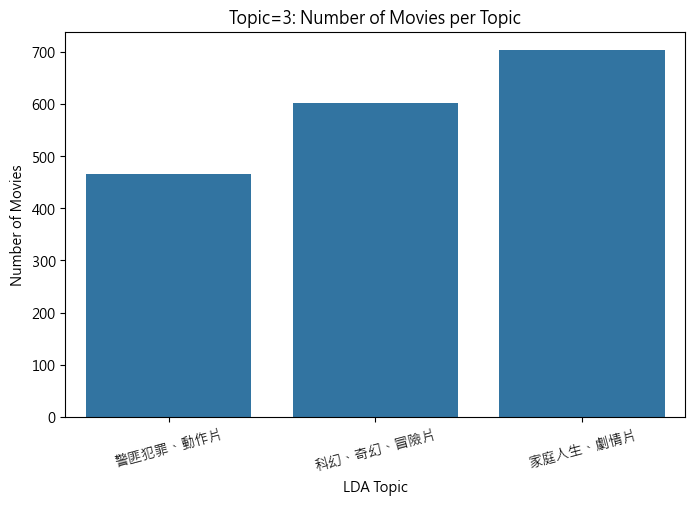

警匪犯罪、動作片 代表電影


,title,overview,genre_list,lda_topic_prob
1223,你他媽的也是,年金馬影展熱門影片原版未通過新聞局電檢大膽性愛畫面同性戀異性戀令人瞠目結舌的豪放青春獲得金球獎最佳外語片提名威尼斯影展最佳劇本最佳新進演員獎歐洲影展項提...,"[劇情, 愛情]",0.998993
1280,巴黎娘,繼露西雅與慾樂園後作風開放惹爭議的異色導演羅虹布尼克推出法國近代影史上最大膽赤裸的都會女性愛慾實錄法國影壇嫩模黛柏哈海薇真實性愛演出毫不畏懼一位身材姣好...,"[劇情, 愛情]",0.998585
1742,天才雷普利,年輕有錢又置身於義大利的豔陽下這是湯姆雷普利所渴望的生活卻是迪基葛林利早已擁有的東西雷普利是個出身平凡生活也毫無值得炫耀的年輕人他受到一個富商之託到義大...,"[驚悚, 犯罪, 劇情]",0.998421
708,十誡,摩西出生在埃及法老下令殺盡希伯來男嬰的白色恐怖時期他的父母不敢收藏便把他放在籃子裡順流而下盼有人收養法老的女兒發現摩西收為自己的兒子摩西長大後對埃及人奴...,"[劇情, 歷史]",0.998323
1778,絕地鬥士,身為前美國超重量級拳王外號冰人的喬治錢伯邁克賈懷特飾雖有一附好身手但自我中心與高傲的他讓自己的退休生活過的辛苦習慣了花用自在的他也沒什麼存款只好答應某家...,"[動作, 犯罪, 驚悚, 劇情]",0.998303
800,玩命關頭,故事發生在唐老大馮迪索和布萊恩保羅沃克重獲自由一年多後他們擺脫暗無天日的亡命生活卻發現這個家脫離現實唐老大忙著和莉蒂蜜雪兒羅卓奎茲飾重新培養感情布萊恩則...,"[動作, 犯罪, 驚悚]",0.998281
981,女子高校拷問社,被稱為永遠蘿莉系平面偶像的女星木島法子在月日未發行的電影女子高校拷問部中上演全裸拷問戲以及同性激情戲女星魂大爆發由在和老虛合作的腳本深見真原作作畫的拷問...,"[劇情, 喜劇]",0.998259
592,記憶拼圖,黑暗中突然出現了一道閃光一名男子被開槍射中頭部兇手正在快速接近中另一道閃光的出現時間卻開始倒轉子彈彈回了槍裡死亡男子的頭部自動癒合持槍的兇手還沒殺人但是...,"[懸疑, 驚悚]",0.998259
701,怪客,故事發生在未來的英國極權社會描述一名年輕女子艾薇被一名被稱為怪客的蒙面男子救了一命怪客不但博學多聞出口成章而且武藝高強溫柔敏感他打算發起一場革命推翻極權...,"[動作, 驚悚, 科幻]",0.998165
1400,特務交鋒,特務交鋒改編自全美暢銷的偵探小說由皮爾斯布洛斯南和龐德女郎歐嘉科里蘭科主演故事橫跨冷戰時期及俄羅斯車臣邊界的恐怖犯罪行動彼得德弗羅在退休之前是美國中央情...,"[犯罪, 動作, 驚悚]",0.998115


科幻、奇幻、冒險片 代表電影


,title,overview,genre_list,lda_topic_prob
1534,星際奇兵,一個美國軍事單位和考古學家利用一個在埃及多年時發現的星際之門帶領眾人來到了一個遙遠的星球的銀河傳奇故事這個發現於古埃及的星際之門因為門上面的古文太過繁複...,"[動作, 冒險, 科幻]",0.998877
685,暮光之城新月,暮光之城無懼的愛續集電影首映單日票房收入萬美元創有史以來最高票房記錄黃金羅盤克里斯魏茲執導影片取景義大利托斯卡尼的古城拍攝佛杜里家族的世居之地營造出小說...,"[冒險, 奇幻, 劇情, 愛情]",0.998866
1307,印第安納瓊斯水晶骷髏王國,時間來到年冷戰高峰期電影一開始偉大的冒險家印第安納瓊斯哈里遜福特飾與助手麥克雷溫斯頓飾在美國西南荒野沙漠一個偏僻的機場正與蘇聯間諜展開一場邀烈的追逐千鈞...,"[冒險, 動作]",0.998647
366,太空漫遊,電影大師史丹利庫伯力克執導的科幻鉅作以近二小時半的篇幅描繪了人類的過去與未來廣集特殊攝影技巧與精準畫面感拍攝而成可謂是空前絕後為了解開神秘的石柱突然屹立...,"[科幻, 懸疑, 冒險]",0.998538
921,人工智慧,這是一個自然資源極度匱乏科技卻是一日千萬里的時代你每個一舉一動都受到監視你所吃的每一種食物都經過遺傳工程改造為你做事的工人也不再是人類他們是機器人園丁管...,"[劇情, 科幻, 冒險]",0.998466
1343,猩球崛起黎明的進擊,當人類的貪婪造成了無可避免的大自然反撲後果是人類將失去家園及一切並面臨異族的迫害基因科學家威爾羅德曼為研發藥物治療阿茲海默症對人猿進行活體基因實驗但在實...,"[科幻, 動作, 劇情, 驚悚]",0.998301
824,暮光之城蝕,神秘吸血軍團現身狼族吸血鬼全面開戰電影一開場西雅圖便發生連串的吸血鬼噬人殺戮事件原來是首集就出現的流浪吸血鬼維多利亞回來展開復仇計畫她為了替被庫倫家族殺...,"[冒險, 奇幻, 劇情, 愛情]",0.998301
251,天劫倒數,地球面臨末日危機偏離軌道的彗星即將衝破大氣層將世界夷為平地隨著全球陷入毀滅倒數的恐慌為了生存挺身而戰的父親約翰傑哈巴特勒飾決心把他的家人帶到選中之地面對...,"[動作, 冒險, 驚悚, 科幻]",0.998301
907,傑克巨人戰紀,人類與巨人族的世界在經過好幾世紀的長久和平協議之後竟然面臨衝突與威脅年輕農夫傑克尼可拉斯霍特飾不小心讓偶然得到的魔豆長成了驚天巨樹更在無意間開啟人類與巨...,"[奇幻, 動作, 冒險, 劇情]",0.998254
1037,第九禁區,二十多年前外星人首度造訪地球人類以為外星人會發動攻擊或是帶來超先進科技造福地球結果兩者皆無其實這些外星人是逃離家鄉的難民人類對他們的處置方法仍然爭論不休...,[科幻],0.998230


家庭人生、劇情片 代表電影


...

Topic × Genre 數量表：


genre_list,冒險,劇情,動作,動畫,喜劇,奇幻,家庭,恐怖,愛情,懸疑,戰爭,歷史,犯罪,科幻,紀錄,西部,電視電影,音樂,驚悚
lda_topic,,,,,,,,,,,,,,,,,,,
0,89,198,159,47,142,48,54,31,78,39,7,19,125,40,6,6,0,10,168
1,321,121,306,122,137,166,132,53,42,18,40,24,21,239,3,8,2,7,112
2,98,290,183,65,189,81,81,161,118,86,13,17,124,75,1,9,3,23,226


Topic × Genre 比例表：


genre_list,冒險,劇情,動作,動畫,喜劇,奇幻,家庭,恐怖,愛情,懸疑,戰爭,歷史,犯罪,科幻,紀錄,西部,電視電影,音樂,驚悚
lda_topic,,,,,,,,,,,,,,,,,,,
0,0.070,0.156,0.126,0.037,0.112,0.038,0.043,0.024,0.062,0.031,0.006,0.015,0.099,0.032,0.005,0.005,0.000,0.008,0.133
1,0.171,0.065,0.163,0.065,0.073,0.089,0.070,0.028,0.022,0.010,0.021,0.013,0.011,0.128,0.002,0.004,0.001,0.004,0.060
2,0.053,0.157,0.099,0.035,0.103,0.044,0.044,0.087,0.064,0.047,0.007,0.009,0.067,0.041,0.001,0.005,0.002,0.012,0.123


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.063787  0.058179       1        1  26.261544
1     -0.102337  0.010422       2        1  32.793500
2      0.038550 -0.068600       3        1  40.944957, topic_info=    Term        Freq       Total Category  logprob  loglift
15    人類  232.000000  232.000000  Default  30.0000  30.0000
39    地球  152.000000  152.000000  Default  29.0000  29.0000
322   殺手   88.000000   88.000000  Default  28.0000  28.0000
63    世界  253.000000  253.000000  Default  27.0000  27.0000
447   生活  255.000000  255.000000  Default  26.0000  26.0000
..   ...         ...         ...      ...      ...      ...
982   陷入   46.864274   81.072387   Topic3  -6.2415   0.3449
506   家族   46.597664   81.002604   Topic3  -6.2472   0.3400
17    傑克   46.397098   84.021653   Topic3  -6.2515   0.2991
63    世界   53.706380  253.820710   Topic3  -6.1053  -0.6602
78    最後   48.225263  164.598910   Topic3  -6.2129  -0.3347

[260 rows x 6 columns], token_table=      Topic      Freq Term
term                      
2637      3  0.952408   一棟
436       1  0.248952   丈夫
436       2  0.049790   丈夫
436       3  0.697066   丈夫
63        1  0.169411   世界
...     ...       ...  ...
220       3  0.893491   麥可
842       1  0.019960   黑幫
842       3  0.958092   黑幫
3239      1  0.731754   龐德
3239      2  0.235207   龐德

[446 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3])

In [18]:
# 主題代表字、代表電影
LDA_TOPIC_NAME = {
    0: '警匪犯罪、動作片',
    1: '科幻、奇幻、冒險片',
    2: '家庭人生、劇情片'
}

topic_keywords_b2 = show_topic_keywords(final_model, num_words=15)
topic_keywords_b2['topic_name'] = topic_keywords_b2['topic'].map(LDA_TOPIC_NAME)
topic_keywords_b2 = topic_keywords_b2[['topic_name', 'keywords']]
display(topic_keywords_b2)

# 6-2. 每部電影指派主要 topic
df_lda_result_b2 = assign_main_topic(df_topic_b, final_model, corpus_b)
display(df_lda_result_b2[['title', 'overview', 'genre_list', 'lda_topic', 'lda_topic_prob']].head(10))

# 6-3. 每個 topic 的電影數量
topic_counts_b2 = df_lda_result_b2['lda_topic'].value_counts().sort_index()
print('topic 電影數量：')
print(topic_counts_b2)

topic_counts_b2_named = topic_counts_b2.rename(index=LDA_TOPIC_NAME)

plt.figure(figsize=(8, 5))
sns.barplot(x=topic_counts_b2_named.index, y=topic_counts_b2_named.values)
plt.title('Topic=3: Number of Movies per Topic')
plt.xlabel('LDA Topic')
plt.ylabel('Number of Movies')
plt.xticks(rotation=15)
plt.show()

# 6-4. 每個 topic 的代表電影
show_representative_movies(
    df_lda_result_b2,
    topic_num=FINAL_TOPIC_NUM,
    top_n=10,
    topic_names=LDA_TOPIC_NAME
)

# 6-5. topic 與 genre 的交叉表
# 因為電影可能有多重 genre，所以先 explode genre_list
lda_genre_exploded = df_lda_result_b2.explode('genre_list')

topic_genre_table = pd.crosstab(
    lda_genre_exploded['lda_topic'],
    lda_genre_exploded['genre_list']
)

print('Topic × Genre 數量表：')
display(topic_genre_table)

# 已依報告需求移除 LDA Topic × Genre 數量熱力圖

# 6-6. topic × genre 比例表
# 每個 topic 內，各 genre 佔比
topic_genre_ratio = topic_genre_table.div(topic_genre_table.sum(axis=1), axis=0)

print('Topic × Genre 比例表：')
display(topic_genre_ratio.round(3))

# 已依報告需求移除 LDA Topic × Genre 比例熱力圖

# 6-7. pyLDAvis：全部資料 topic=2
vis_b2 = make_pyldavis(final_model, corpus_b, dictionary_b)
vis_b2

In [19]:
# 延伸視覺化：全部資料 topic=4、5 延伸比較
EXT_TOPIC_NUM_LIST = [4, 5]

ext_vis_dict = {}

for ext_topic_num in EXT_TOPIC_NUM_LIST:
    print('\n' + '=' * 80)
    print(f'Extension Model：全部電影資料，topic={ext_topic_num}')

    ext_model = model_set_b.get(ext_topic_num)

    if ext_model is None:
        ext_model = train_lda(corpus_b, dictionary_b, ext_topic_num)

    ext_perplexity, ext_npmi, ext_npmi_per_topic = evaluate_lda(
        ext_model,
        corpus_b,
        docs_b,
        dictionary_b
    )

    print('Perplexity：', ext_perplexity)
    print('NPMI：', ext_npmi)
    print('每個 topic 的 NPMI：')
    print(ext_npmi_per_topic)

    show_topic_keywords(ext_model, num_words=15)

    vis = make_pyldavis(ext_model, corpus_b, dictionary_b)
    ext_vis_dict[ext_topic_num] = vis

    display(vis)


Extension Model：全部電影資料，topic=4
Perplexity： 242.81384055399656
NPMI： -0.12975371434750618
每個 topic 的 NPMI：
[-0.2351010509321446, -0.13015856976315093, -0.0486996542357508, -0.1050555824589784]


,topic,keywords
0,0,生活、故事、最後、世界、女子、兩個、犯罪、公司、警察、導演、機器人、美麗、擁有、發生、威廉
1,1,人類、世界、地球、任務、變成、最後、外星人、未來、動物、找到、機器人、危機、公主、意外、生存
2,2,父親、妻子、生活、女兒、發生、意外、人生、美國、小鎮、過去、家庭、無法、最後、約翰、逐漸
3,3,美國、生活、任務、神秘、殺手、故事、傑克、找到、冒險、世界、過去、秘密、紐約、組織、龐德


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.078207  0.062008       1        1  19.112441
1      0.104621  0.043826       2        1  24.109375
2     -0.054600 -0.039226       3        1  31.926605
3      0.028186 -0.066607       4        1  24.851579, topic_info=     Term        Freq       Total Category  logprob  loglift
15     人類  232.000000  232.000000  Default  30.0000  30.0000
39     地球  151.000000  151.000000  Default  29.0000  29.0000
63     世界  253.000000  253.000000  Default  28.0000  28.0000
1999  外星人   46.000000   46.000000  Default  27.0000  27.0000
1617  機器人   65.000000   65.000000  Default  26.0000  26.0000
...   ...         ...         ...      ...      ...      ...
318    唯一   28.610731   77.192067   Topic4  -6.2357   0.3997
73     意外   32.757939  149.125611   Topic4  -6.1003  -0.1234
678    未來   29.850359   94.862436   Topic4  -6.1933   0.2360
19     全新   27.526367   68.406727   Topic4  -6.2743   0.4819
250    女兒   28.524675  116.444593   Topic4  -6.2387  -0.0144

[322 rows x 6 columns], token_table=      Topic      Freq Term
term                      
450       1  0.217266   一天
450       2  0.188297   一天
450       3  0.521438   一天
450       4  0.086906   一天
227       1  0.617622   一樁
...     ...       ...  ...
842       3  0.792155   黑幫
842       4  0.178235   黑幫
3239      1  0.026134   龐德
3239      2  0.052269   龐德
3239      4  0.914700   龐德

[635 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4])


Extension Model：全部電影資料，topic=5
Perplexity： 249.08031302476786
NPMI： -0.1345018479874349
每個 topic 的 NPMI：
[-0.1794315732351135, -0.14318359503764405, -0.05468918617480269, -0.11556314410038385, -0.1796417413892304]


,topic,keywords
0,0,生活、最後、故事、世界、法蘭克、警探、調查、犯罪、機器人、女子、警察、公司、兩個、威廉、美麗
1,1,人類、世界、地球、任務、外星人、公主、尋找、王國、未來、危險、危機、意外、機器人、變成、國王
2,2,妻子、生活、父親、女兒、發生、美國、意外、世界、小鎮、無法、人生、逐漸、關係、最後、家庭
3,3,生活、美國、殺手、任務、傑克、神秘、過去、找到、世界、故事、秘密、紐約、冒險、組織、龐德
4,4,故事、吸血鬼、父親、約翰、女孩、找到、美國、最後、愛情、唯一、亞瑟、一部、一次、事件、生命


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.086860  0.064218       1        1  15.957101
1      0.119126  0.040532       2        1  22.068146
2     -0.038007 -0.001669       3        1  27.661746
3      0.010704  0.011151       4        1  21.549211
4     -0.004962 -0.114232       5        1  12.763795, topic_info=     Term        Freq       Total Category  logprob  loglift
15     人類  234.000000  234.000000  Default  30.0000  30.0000
39     地球  153.000000  153.000000  Default  29.0000  29.0000
1063  吸血鬼   65.000000   65.000000  Default  28.0000  28.0000
1999  外星人   46.000000   46.000000  Default  27.0000  27.0000
784    故事  183.000000  183.000000  Default  26.0000  26.0000
...   ...         ...         ...      ...      ...      ...
483    死亡   16.449628   69.458649   Topic5  -6.1229   0.6181
37     危機   15.921169   84.821921   Topic5  -6.1555   0.3857
447    生活   18.839372  255.597645   Topic5  -5.9872  -0.5491
15     人類   18.544880  234.109672   Topic5  -6.0030  -0.4770
427    發生   16.389146  132.023691   Topic5  -6.1266  -0.0278

[379 rows x 6 columns], token_table=      Topic      Freq Term
term                      
450       1  0.216803   一天
450       2  0.158989   一天
450       3  0.520326   一天
450       4  0.086721   一天
450       5  0.028907   一天
...     ...       ...  ...
842       4  0.199140   黑幫
842       5  0.059742   黑幫
3239      2  0.026110   龐德
3239      4  0.861644   龐德
3239      5  0.104442   龐德

[918 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5])

### GuidedLDA

In [20]:
GUIDED_TOPIC_NUM = 3

# 注意：seed words 要盡量使用「已經出現在 dictionary_b 裡的詞」
seed_topic_list = [
    # Topic 0：犯罪 / 動作 / 追查
    ['殺手', '犯罪', '警察', '警探', '調查', '任務', '兇手', '追殺', '黑幫', '案件'],

    # Topic 1：科幻 / 奇幻 / 冒險
    ['人類', '地球', '宇宙', '未來', '機器人', '外星人', '冒險', '魔法', '王國', '怪獸', '拯救'],

    # Topic 2：家庭 / 人生 / 情感
    ['父親', '母親', '女兒', '妻子', '家庭', '人生', '朋友', '孩子', '小鎮', '關係', '愛情']
]

word2id = dictionary_b.token2id

seed_topics = {}
missing_seed_words = []

for topic_id, seed_words in enumerate(seed_topic_list):
    for word in seed_words:
        if word in word2id:
            seed_topics[word2id[word]] = topic_id
        else:
            missing_seed_words.append(word)

print('成功放入 GuidedLDA 的 seed word 數量：', len(seed_topics))
print('不在 dictionary_b 中的 seed words：', missing_seed_words)

成功放入 GuidedLDA 的 seed word 數量： 32
不在 dictionary_b 中的 seed words： []


In [21]:
X_guided = corpus2dense(
    corpus_b,
    num_terms=len(dictionary_b),
    num_docs=len(corpus_b)
).T.astype(np.int64)

print('GuidedLDA DTM shape：', X_guided.shape)

GuidedLDA DTM shape： (1770, 3668)


In [22]:
guided_model = guidedlda.GuidedLDA(
    n_topics=GUIDED_TOPIC_NUM,
    n_iter=200,
    random_state=RANDOM_STATE,
    refresh=20
)

guided_model.fit(
    X_guided,
    seed_topics=seed_topics,
    seed_confidence=0.30
)

INFO:guidedlda:n_documents: 1770
INFO:guidedlda:vocab_size: 3668
INFO:guidedlda:n_words: 58790
INFO:guidedlda:n_topics: 3
INFO:guidedlda:n_iter: 200
INFO:guidedlda:<0> log likelihood: -583459
INFO:guidedlda:<20> log likelihood: -504675
INFO:guidedlda:<40> log likelihood: -500511
INFO:guidedlda:<60> log likelihood: -498221
INFO:guidedlda:<80> log likelihood: -496092
INFO:guidedlda:<100> log likelihood: -495177
INFO:guidedlda:<120> log likelihood: -494300
INFO:guidedlda:<140> log likelihood: -493956
INFO:guidedlda:<160> log likelihood: -493649
INFO:guidedlda:<180> log likelihood: -493509
INFO:guidedlda:<199> log likelihood: -493014


In [23]:
n_top_words = 15
vocab = np.array([dictionary_b[i] for i in range(len(dictionary_b))])

guided_topic_rows = []

for topic_id, topic_dist in enumerate(guided_model.topic_word_):
    top_word_ids = np.argsort(topic_dist)[::-1][:n_top_words]
    top_words = vocab[top_word_ids]
    guided_topic_rows.append({
        'guided_topic': topic_id + 1,
        'seed_theme': ['警匪犯罪、動作片', '科幻、奇幻、冒險片', '家庭人生、劇情片'][topic_id],
        'keywords': '、'.join(top_words)
    })

guided_topic_keywords_df = pd.DataFrame(guided_topic_rows)
display(guided_topic_keywords_df)

,guided_topic,seed_theme,keywords
0,1,警匪犯罪、動作片,美國、任務、殺手、導演、行動、組織、英國、調查、死亡、過去、秘密、故事、探員、遊戲、一次
1,2,科幻、奇幻、冒險片,人類、世界、地球、未來、出現、拯救、意外、找到、英雄、神秘、冒險、擁有、尋找、再度、故事
2,3,家庭人生、劇情片,生活、父親、最後、女兒、家庭、人生、母親、愛情、意外、妻子、故事、小鎮、吸血鬼、孩子、無法


In [24]:
guided_doc_topic = guided_model.doc_topic_

df_guided_result = df_topic_b.copy()
df_guided_result['guided_topic'] = guided_doc_topic.argmax(axis=1)
df_guided_result['guided_topic_prob'] = guided_doc_topic.max(axis=1)

print('GuidedLDA 結果前 10 筆：')
display(
    df_guided_result[
        ['title', 'overview', 'genre_list', 'guided_topic', 'guided_topic_prob']
    ].head(10)
)


GuidedLDA 結果前 10 筆：


,title,overview,genre_list,guided_topic,guided_topic_prob
0,超級瑪利歐銀河電影版,面對反派勢力再度崛起瑪利歐也為蘑菇王國挺身而出迎戰大喊先過我這一關碧姬公主則與奇諾比奧迅速打包啟程前往銀河尋找羅潔塔公主一群色彩繽紛又可愛的奇可也加入行列,"[家庭, 喜劇, 冒險, 奇幻, 動畫]",1,0.998669
2,阿凡達火與燼,這次的故事敘述從人類歸化納美族並當上首領的傑克蘇里妻子納美戰士奈蒂莉及蘇里的家人一同在經歷奮戰與傷痛後依然必須展開全新冒險也將面臨新登場反派的威脅,"[科幻, 冒險, 奇幻]",1,0.849226
3,極限返航,科學老師萊倫格雷斯在一艘距離地球好幾光年的太空船上醒來卻對自己的身分和來到這裡的原因一無所知隨著記憶逐漸恢復他開始揭開任務的真相解開一種神祕物質導致太陽...,"[科幻, 冒險]",1,0.866134
4,降世神通最後的氣宗,安意外得知一股古老力量或許能拯救他的族群免於滅絕在夥伴們的協助下他踏上一段橫跨世界的尋找之旅試圖在這股力量落入歹人之手威脅到他們傾盡一切才換來的和平之前...,"[動畫, 動作, 冒險, 奇幻]",1,0.999232
5,停屍間助手,殯葬學畢業生麗貝卡歐文斯在河畔殯儀館找到一份夜班工作這份工作起初看似平常但很快便變得詭異起來她開始面對可怕的超自然力量,"[恐怖, 懸疑]",1,0.499644
6,狸想世界,熱愛動物的梅寶逮到了一個機會藉由新科技讓意識進入到栩栩如生的機器動物身上有了能夠和動物溝通的新能力她在自家後院揭開了一個連作夢也想不到的神祕世界,"[動畫, 家庭, 科幻, 喜劇, 冒險]",1,0.998891
7,狂鯊風暴,在一場毀滅性的颶風中一個沿海小鎮正奮力對抗大自然的憤怒以及鯊魚的襲擊在傾盆大雨飛散的殘骸和伸手不見五指的黑暗中他們團結一心勇敢面對致命的掠食者努力在風暴...,"[恐怖, 驚悚]",1,0.811603
9,凸槌拍檔,在這部重口味尺度炸裂的喜劇中行銷專員布萊德與伊萊賈放手一搏大膽提案讓全方位包覆保險套品牌冠名贊助世界盃沒想到兩人在巴西的酒醉狂歡引爆全球醜聞暴怒球迷窮凶...,"[喜劇, 動作, 冒險]",2,0.555186
10,天眼浩劫,一名隱居在蘇格蘭偏遠小島的男子遠離現代社會不與外界接觸卻在拯救一名落海的少女後引發了一連串危機並導致他的住處小島遭到襲擊這迫使他面對自己的過往並作出反擊,"[動作, 犯罪, 驚悚]",1,0.578560
11,天劫倒數大遷徙,倖存的蓋瑞提一家必須離開安全的格陵蘭島避難所踏上危險的旅程穿越歐洲滿目瘡痍的冰凍荒原尋找新的家園,"[冒險, 驚悚, 科幻]",1,0.998337


GuidedLDA topic 電影數量：
guided_topic
0    557
1    624
2    589
Name: count, dtype: int64


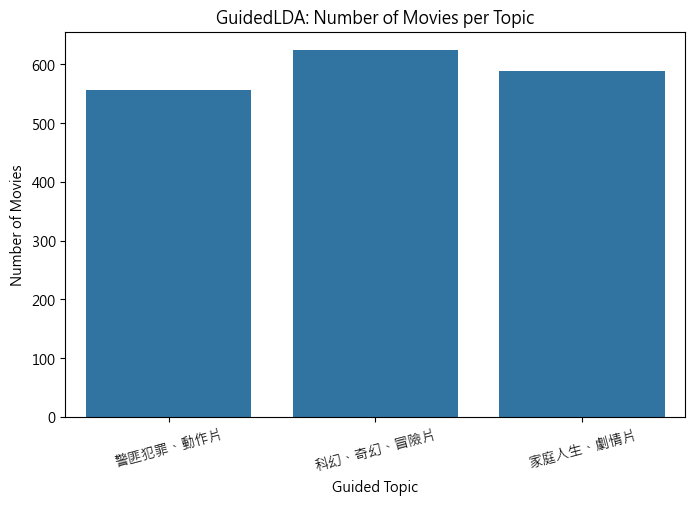

In [25]:
GUIDED_TOPIC_NAME = {
    0: '警匪犯罪、動作片',
    1: '科幻、奇幻、冒險片',
    2: '家庭人生、劇情片'
}
guided_topic_counts = df_guided_result['guided_topic'].value_counts().sort_index()
print('GuidedLDA topic 電影數量：')
print(guided_topic_counts)

guided_topic_counts_named = guided_topic_counts.rename(index=GUIDED_TOPIC_NAME)

plt.figure(figsize=(8, 5))
sns.barplot(x=guided_topic_counts_named.index, y=guided_topic_counts_named.values)
plt.title('GuidedLDA: Number of Movies per Topic')
plt.xlabel('Guided Topic')
plt.ylabel('Number of Movies')
plt.xticks(rotation=15)
plt.show()

In [26]:
GUIDED_TOPIC_NAME = {
    0: '警匪犯罪、動作片',
    1: '科幻、奇幻、冒險片',
    2: '家庭人生、劇情片'
}

for topic_id in range(GUIDED_TOPIC_NUM):
    print('' + '=' * 70)
    print(f'{GUIDED_TOPIC_NAME.get(topic_id, "未命名主題")} 代表電影')

    display(
        df_guided_result[df_guided_result['guided_topic'] == topic_id]
        .sort_values('guided_topic_prob', ascending=False)
        [['title', 'overview', 'genre_list', 'guided_topic_prob']]
        .head(10)
    )

警匪犯罪、動作片 代表電影


,title,overview,genre_list,guided_topic_prob
1465,光榮之路,史丹利庫伯力克年執導經典反戰電影透過一宗軍事醜聞的來龍去脈批判法國政治體制讓此片在法國遭禁映長達年之久寇克道格拉斯阿道夫曼吉主演故事改編自的同名史實小說...,"[戰爭, 劇情]",0.999546
1627,小時死亡對峙,改編自真實事件年月日東尼基里西斯闖入全盛貸款公司總裁理查霍爾的辦公室以一把改造過的獵槍劫持他為人質並將那把槍以一條死亡連線從扳機連接到人質的脖子上也與自...,"[犯罪, 劇情, 驚悚]",0.999334
1744,頭號公敵,改編自美國年代聞名的銀行大盜約翰狄林杰的真實故事聯邦探員如何與黑幫份子鬥智鬥勇將一幫同夥逮捕入獄的故事現代版的羅賓漢傳奇故事強尼戴普飾演美國史上最厲害的...,"[犯罪, 歷史, 劇情]",0.999286
1772,湯姆克蘭西之冷血悍將,美國海豹部隊隊員約翰凱利為了遭俄羅斯士兵謀殺其懷孕的妻子而展開行動當他的部隊與中央情報局任務合作時意外地揭發了一個大陰謀威脅要在一場全面戰爭中吞併美國和俄羅斯,"[動作, 驚悚, 戰爭]",0.999260
1773,霹靂彈,霹靂彈英語是年拍的第部詹姆士龐德系列影片史恩康納萊於年主演的第七號情報員勇奪巡弋飛彈就是本片的重拍版本惡魔黨是一個世界性的恐怖組織在某次計劃中他們攔截了...,"[冒險, 動作, 驚悚]",0.999260
1727,玩命特攻武演行動,超級間諜奧森福瓊傑森史塔森飾和他的頂尖特務團隊招募了好萊塢巨星丹尼法蘭西斯柯喬許哈奈特飾為他們執行臥底任務以阻止億萬富翁軍火商蒙瑞格西蒙茲休葛蘭飾出售一...,"[動作, 喜劇, 驚悚, 冒險]",0.999232
1352,怒火邊界毒刑者,聲東擊西橫掃毒梟美墨邊界的毒品交易日益嚴重販毒集團愈發囂張不僅非法走私毒品甚至偷渡恐怖分子進入美國聯邦探員麥特喬許布洛林飾決定再次聯手神秘的前特工人員亞...,"[動作, 犯罪, 驚悚]",0.999201
524,復仇反擊戰,一名天資聰穎卻極為內向的中情局解碼員在妻子於倫敦的恐怖攻擊中喪命後頓時陷入極度悲憤在長官拒絕對此採取行動後他決定親自出馬踏上一段橫跨全球的危險長征只為找...,"[驚悚, 動作]",0.999168
1821,唐人街,描述三十年代洛杉磯一名私家偵探為貴婦所僱用偵察其夫外遇不料卻由此涉入一宗複雜的財閥陰謀與亂倫慘劇中這是一部情節複雜而戲味濃郁的懷舊偵察片編導演均有精彩表...,"[犯罪, 劇情, 懸疑, 驚悚]",0.999168
1014,迷霧追魂手,在末來的世界中幫派份子無法無天連警察也束手無策妻女皆被殺害的麥斯梅爾吉勃遜飾於是起身對抗他騎著馬力強勁的機車與幫派份子展開一場生死之鬥全片於澳洲荒漠拍攝...,"[冒險, 動作, 驚悚, 科幻]",0.999168


科幻、奇幻、冒險片 代表電影


,title,overview,genre_list,guided_topic_prob
1764,降世神通最後的氣宗,本片故事具有中國傳統的神話色彩世界被四大神力氣火水土支配著烈火國一直在全世界開戰企圖征服其它的三個部族大氣牧族水族部落以及大地國世界各地的村民極力保護少...,"[動作, 冒險, 奇幻]",0.999688
1083,魔獸崛起,故事敘述兩個截然不同的世界首次展開激烈衝突一直以來祥和平靜的艾澤拉斯國度即將面臨一場足以摧毀人類文明的大戰一群驍勇善戰魁梧壯碩的獸人戰士逃離他們瀕死的家...,"[動作, 冒險, 奇幻]",0.999592
939,異形浴火重生,蕾普莉死後年一群叛變的走私者及科學家在太空艦上秘密進行了一項喪失人性的實驗死後的蕾普莉被軍方重新複製被賦予了生命並加入異形強大基因蕾普莉重生後擁有了更強...,"[科幻, 恐怖, 動作]",0.999584
64,復仇者聯盟無限之戰,漫威電影宇宙年集大成巔峰之作史上最強超級英雄全面集結我們打不了的戰爭他們為我們挺身而出地球的存亡宇宙的平衡在薩諾斯毀天滅地以前尚有復仇者聯盟復仇者聯盟系...,"[冒險, 動作, 科幻]",0.999513
976,哥吉拉大戰金剛,兩位神級巨獸展開史詩般的殊死一戰當傳奇正面對決時世界的命運危在旦夕金剛與牠的保護者踏上危險的旅程尋找牠真正的家園同行的還有吉雅這名年輕的小孤女與金剛間有...,"[動作, 科幻, 冒險]",0.999488
943,星際大戰三部曲西斯大帝的復仇,探索在三部曲星際大戰西斯大帝的復仇電影中黑暗勢力的真正力量在複製人大戰開打後數年高貴的絕地武士帶領著為數眾多的複製人軍團與分離主義者展開整銀河間的對抗當...,"[冒險, 動作, 科幻]",0.999488
1615,電影哆啦夢大雄的南極冰天雪地大冒險,大雄一群人受不了盛夏的酷熱於是前往漂浮在南太平洋的巨大冰山他們在那裏用秘密道具冰雕工藝組打算製造遊樂園卻發現一個被冰封住的金手環為了尋找金手環的主人經過...,"[動畫, 冒險, 奇幻, 家庭, 科幻, 喜劇]",0.999460
371,星際大戰七部曲原力覺醒,路克天行者消失了邪惡的第一軍團於這段時間已經從帝國的廢墟中崛起他們不會休息直到消滅路克最後的絕地武士莉亞歐嘉納將軍帶領著共和國頑強的在抵抗她急切地希望找...,"[冒險, 動作, 科幻]",0.999429
1296,驚奇超人,驚奇漫晝經典再上大銀幕一場外太空實驗旅行讓四名實險隊員遭受不明宇宙輻射照射意外賦有超能力隊長奇幻人李德的身體能夠任意延伸隱形女蘇可以隱形還能讓其他東西隱...,"[動作, 奇幻, 科幻]",0.999429
448,黑豹,黑豹的故事將接續在美國隊長英雄內戰之後帝查拉返回擁有先進科技卻與世隔絕的瓦干達接下王位然而積怨已久的宿敵再度出現將他捲入一場波及瓦干達全國甚至全世界安危...,"[動作, 冒險, 科幻]",0.999376


家庭人生、劇情片 代表電影


,title,overview,genre_list,guided_topic_prob
403,派特的幸福劇本,前歷史老師派特布萊德利庫柏飾在精神病院待了八個月後終於出院現在的他與爸媽住在一起而出院後他最想做的事就是和離異的妻子重修舊好派特不願接受他和妻子的關係已...,"[劇情, 喜劇, 愛情]",0.999460
135,哈姆奈特,年英國貧困的拉丁語家教威廉莎士比亞遇見自由奔放的艾格妮絲兩人深受對方吸引展開一段熾熱戀情並迅速步入婚姻與三個孩子過著幸福的生活但當遠在倫敦的威廉戲劇事業...,"[劇情, 愛情, 歷史]",0.999460
1143,大開眼戒,醫生哈維與在藝廊工作的的太太愛麗絲是一對人人稱羨的富裕夫妻一天夜晚在一次晚宴結束後哈維故意和愛麗絲討論他與不同女病人之間打情罵俏的狀況想藉此調侃老婆愛麗...,"[劇情, 驚悚, 懸疑]",0.999376
223,格雷的五十道陰影,格雷的五十道陰影原作被稱為成人版暮光之城講述女大學生安娜與年輕企業鉅子格雷間看似高壓控制令人窒息卻又無法抗拒的愛情性愛關係兩人的相識在於安娜為了校刊對格...,"[劇情, 愛情, 驚悚]",0.999376
1518,女狼俱樂部,一位身材火辣面容姣好又有一副好嗓子的紐澤西小女孩高中畢業後來離開家前往紐約奮鬥在幾經挫折後終於在一家名為女狼俱樂部的酒吧找一份服務生的工作女狼俱樂部的四...,"[喜劇, 劇情, 音樂, 愛情]",0.999376
842,女巫,世紀的新英格蘭虔誠的清教徒威廉一家人被逐出小鎮只好搬遷至傳聞藏有女巫的森林旁隨著作物歉收牲畜暴戾難安加上一名嬰孩失蹤夫妻二人的關係陷入緊張精神近於崩潰不...,[恐怖],0.999355
386,殘夏,安妮是一名律師和丈夫皮埃爾以及兩個領養的女兒原本過著平穩幸福的生活直到西奧搬進了他們家中西奧是皮埃爾與前妻的孩子性格叛逆且無禮然而在與安妮的幾次相處之後...,[劇情],0.999334
893,愛上平行時空的你,艾莉莎搬進了聖彼得堡一間寬敞的公寓公寓裏的鏡子卻開始出現故障它向這位年輕的房客展現了同一個公寓的平行世界只不過在這個平行世界裏生活的不是艾麗莎而是和她搶...,"[喜劇, 愛情, 奇幻]",0.999311
806,美國心玫瑰情,賴特斯班罕住在一個典型的美國小鎮中年危機的他突然對生活感到不滿意他和太太洛琳的性生活不協調他和女兒小珍的關係陷入冷戰他在公司的職位岌岌可危於是他急於尋求...,[劇情],0.999260
982,天才的禮物,法蘭克艾德勒克里斯伊凡飾獨自撫養著他的天才外甥女瑪莉麥肯娜葛瑞絲飾兩人住在佛羅里達州靠海的小鎮法蘭克竭盡所能地讓瑪莉過著正常七歲小孩的生活但這一切平靜就...,"[劇情, 喜劇]",0.999232


In [27]:
term_frequency = np.asarray(X_guided.sum(axis=0)).ravel()
doc_lengths = np.asarray(X_guided.sum(axis=1)).ravel()

guided_vis = pyLDAvis.prepare(
    topic_term_dists=guided_model.topic_word_,
    doc_topic_dists=guided_model.doc_topic_,
    doc_lengths=doc_lengths,
    vocab=[dictionary_b[i] for i in range(len(dictionary_b))],
    term_frequency=term_frequency,
    sort_topics=False
)

guided_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.306360  0.007774       1        1  31.199816
1      0.145613 -0.239925       2        1  35.430730
2      0.160747  0.232151       3        1  33.369453, topic_info=    Term        Freq       Total Category  logprob  loglift
15    人類  244.000000  244.000000  Default  30.0000  30.0000
447   生活  270.000000  270.000000  Default  29.0000  29.0000
39    地球  159.000000  159.000000  Default  28.0000  28.0000
63    世界  267.000000  267.000000  Default  27.0000  27.0000
944   美國  211.000000  211.000000  Default  26.0000  26.0000
..   ...         ...         ...      ...      ...      ...
450   一天   51.912677   71.896264   Topic3  -5.9346   0.7719
427   發生   63.890223  138.768756   Topic3  -5.7270   0.3219
784   故事   69.878995  195.663849   Topic3  -5.6374   0.0679
63    世界   55.905193  267.539574   Topic3  -5.8605  -0.4681
944   美國   53.908935  211.625342   Topic3  -5.8969  -0.2700

[207 rows x 6 columns], token_table=      Topic      Freq Term
term                      
450       2  0.278179   一天
450       3  0.723264   一天
168       2  1.001032   一座
227       1  1.000724   一樁
265       1  0.572341   一次
...     ...       ...  ...
707       3  1.001063   靈魂
948       1  0.855717   麥克
948       3  0.145654   麥克
842       1  1.001347   黑幫
3239      1  1.001174   龐德

[253 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3])

### 主題隨時間變化：每年 topic 分布

In [28]:
DATE_COL = 'release_date'   # 如果你的日期欄位不是這個，請改成正確欄位名稱

# 使用目前 final_model 的結果，例如 topic=3
df_time_topic = df_lda_result_b2.copy()

# 若你現在主模型其實是 topic=3，請確認 df_lda_result_b2 是用 FINAL_TOPIC_NUM=3 跑出來的
# 或者重新命名成 df_lda_result_final 會更清楚

df_time_topic[DATE_COL] = pd.to_datetime(df_time_topic[DATE_COL], errors='coerce')
df_time_topic = df_time_topic.dropna(subset=[DATE_COL]).copy()

df_time_topic['year'] = df_time_topic[DATE_COL].dt.year
df_time_topic['month'] = df_time_topic[DATE_COL].dt.to_period('M').astype(str)

In [29]:
monthly_topic_count = pd.crosstab(
    df_time_topic['month'],
    df_time_topic['lda_topic']
)

display(monthly_topic_count)

lda_topic,0,1,2
month,,,
1936-02,0,0,1
1938-01,1,0,0
1939-08,0,1,0
1939-12,0,0,1
1940-02,1,0,0
...,...,...,...
2026-07,0,1,0
2026-08,1,0,0
2026-10,0,1,1


In [30]:
yearly_topic_count = pd.crosstab(
    df_time_topic['year'],
    df_time_topic['lda_topic']
)

display(yearly_topic_count)

lda_topic,0,1,2
year,,,
1936,0,0,1
1938,1,0,0
1939,0,1,1
1940,2,1,0
1942,0,1,0
...,...,...,...
2023,17,28,35
2024,25,27,39
2025,48,67,77


In [31]:
yearly_topic_ratio = yearly_topic_count.div(
    yearly_topic_count.sum(axis=1),
    axis=0
)

display(yearly_topic_ratio.round(3))

lda_topic,0,1,2
year,,,
1936,0.000,0.000,1.000
1938,1.000,0.000,0.000
1939,0.000,0.500,0.500
1940,0.667,0.333,0.000
1942,0.000,1.000,0.000
...,...,...,...
2023,0.212,0.350,0.438
2024,0.275,0.297,0.429
2025,0.250,0.349,0.401


GuidedLDA 千禧年前後 Topic 數量表：


guided_topic_name,家庭人生、劇情片,警匪犯罪、動作片,科幻、奇幻、冒險片
era,,,
Pre-2000,121,123,92
2000+,468,434,532


GuidedLDA 千禧年前後 Topic 比例表：


guided_topic_name,家庭人生、劇情片,警匪犯罪、動作片,科幻、奇幻、冒險片
era,,,
Pre-2000,0.360,0.366,0.274
2000+,0.326,0.303,0.371


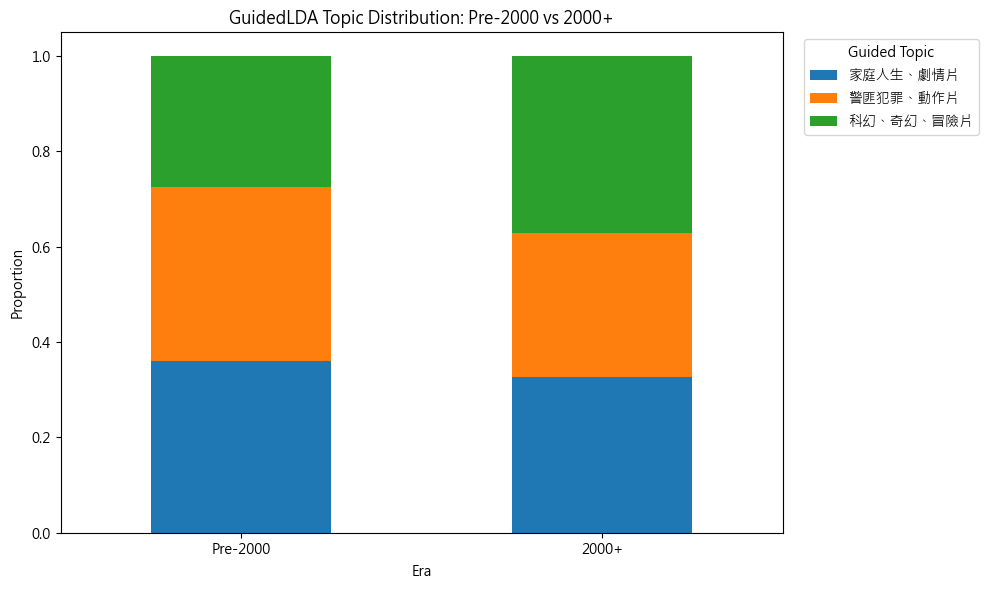

In [32]:
if 'release_date' in movies.columns:
    df_guided_result['release_date'] = movies.loc[df_guided_result.index, 'release_date'].values

if 'release_date' in df_guided_result.columns:
    df_guided_result['release_date'] = pd.to_datetime(
        df_guided_result['release_date'],
        errors='coerce'
    )

    df_guided_time = df_guided_result.dropna(subset=['release_date']).copy()
    df_guided_time['year'] = df_guided_time['release_date'].dt.year

    df_guided_time['era'] = np.where(
        df_guided_time['year'] < 2000,
        'Pre-2000',
        '2000+'
    )

    GUIDED_TOPIC_NAME = {
        0: '警匪犯罪、動作片',
        1: '科幻、奇幻、冒險片',
        2: '家庭人生、劇情片'
    }

    df_guided_time['guided_topic_name'] = df_guided_time['guided_topic'].map(GUIDED_TOPIC_NAME)

    era_order = ['Pre-2000', '2000+']
    topic_order = [
        '家庭人生、劇情片',
        '警匪犯罪、動作片',
        '科幻、奇幻、冒險片'
    ]

    era_topic_count = pd.crosstab(
        df_guided_time['era'],
        df_guided_time['guided_topic_name']
    ).reindex(index=era_order, columns=topic_order)

    print('GuidedLDA 千禧年前後 Topic 數量表：')
    display(era_topic_count)

    era_topic_ratio = pd.crosstab(
        df_guided_time['era'],
        df_guided_time['guided_topic_name'],
        normalize='index'
    ).reindex(index=era_order, columns=topic_order)

    print('GuidedLDA 千禧年前後 Topic 比例表：')
    display(era_topic_ratio.round(3))

    era_topic_ratio.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 6)
    )

    plt.title('GuidedLDA Topic Distribution: Pre-2000 vs 2000+')
    plt.xlabel('Era')
    plt.ylabel('Proportion')
    plt.legend(title='Guided Topic', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

else:
    print('找不到 release_date 欄位，無法進行時間分析。')